Based on https://www.youtube.com/watch?v=UjOsM5iUWwY

# Housing Prices

Strategy will be

- Import packages

- Import Data
    -labeled/unlabed

- Check Data 
    - Target Feature Distribution
    - Check Outliers
    - Check Nan values
    - Check Correlations

- Data clean up (NO LEAKAGE)
    - Rename columns

- Split train/holdout datasets

- Data clean up (RISK OF LEAKAGE)
    - Imput missing data
    - Outliers
    - Changing Data Types

- Feature Engineering
    - Create new features
    - Deal with skew in the target variable (and maybe features depending on model)
    - Feature Transformation (scaling). Here it is not needed
    - Encoding Categorical through ordered encoding, label encoding, target encoding or one-hot encoding
    - Feature Selection

- Machine Learning
    - Hyperparameter tuning
    - Model training
    - Prediction
    - Analysis  

# Import Packages

In [1]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
from sklearn.model_selection import train_test_split
import scipy.stats

import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score

import optuna
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression



# Import Data

In [2]:
df_train = pd.read_csv("./input/train.csv",index_col = "Id")
df_inference = pd.read_csv("./input/test.csv",index_col = "Id")

# Check Data

In [3]:
df_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [5]:
df_inference.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

### Target distribution

Text(0.5, 0, 'Sale Price (USD)')

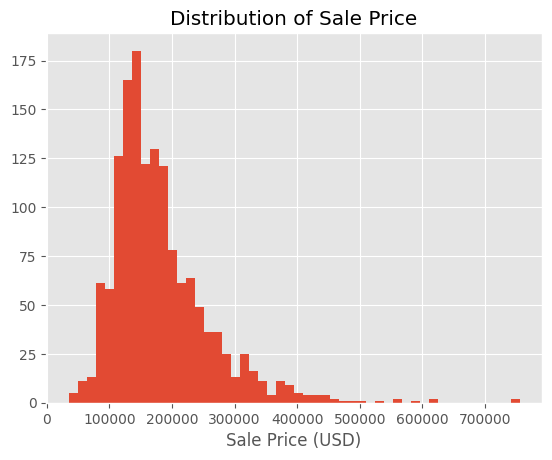

In [6]:
ax = df_train["SalePrice"].hist(bins = 50)
ax.set_title("Distribution of Sale Price")
ax.set_xlabel("Sale Price (USD)")


Text(0.5, 0, 'Log(Sale Price) (Log(USD))')

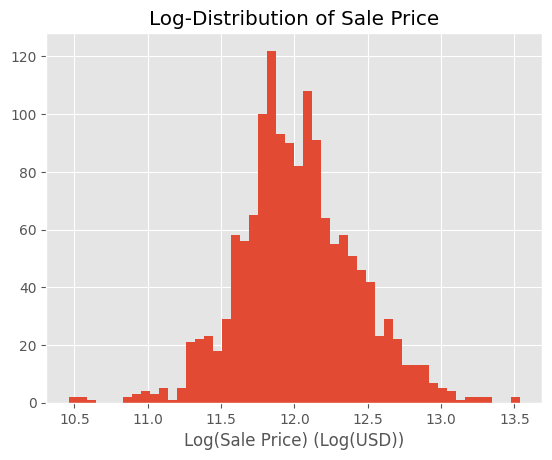

In [7]:
ax = df_train["SalePrice"].apply(lambda x : np.log(x)).hist(bins = 50)
ax.set_title("Log-Distribution of Sale Price")
ax.set_xlabel("Log(Sale Price) (Log(USD))")

## Check outliers

In [8]:
numerical_df = df_train.select_dtypes(exclude=['object'])
# numerical_df = numerical_df.drop(["Id"], axis=1)

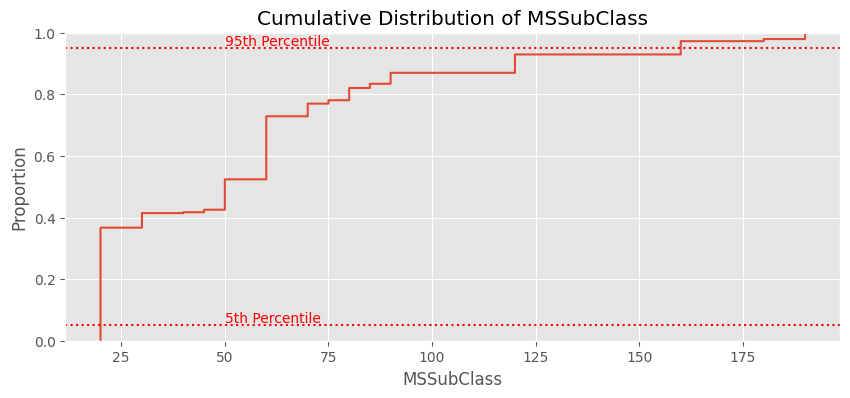

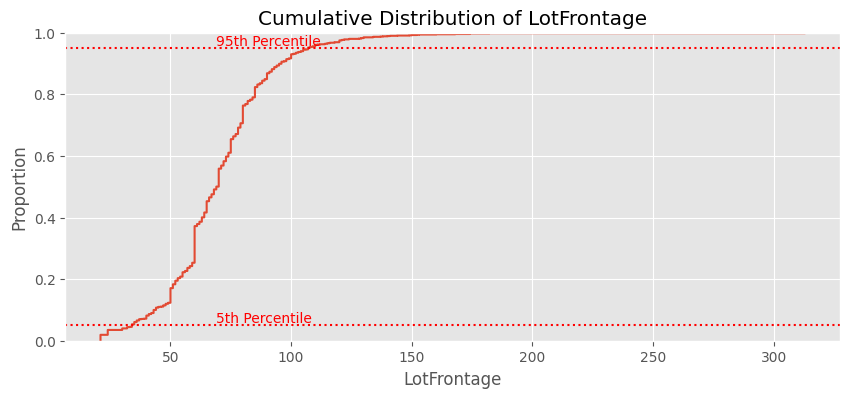

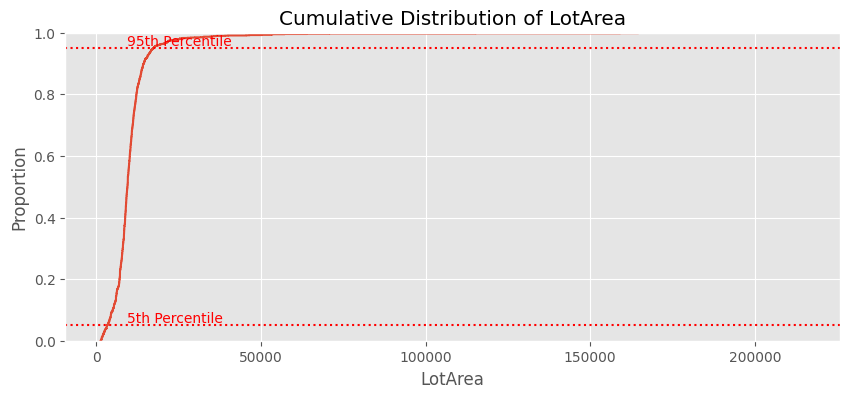

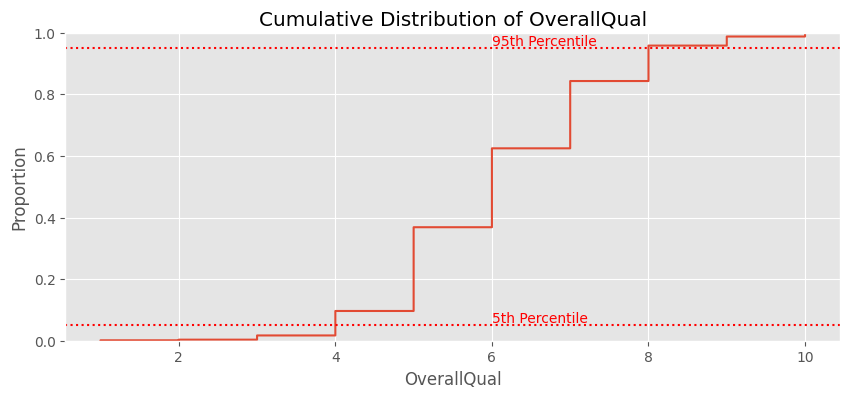

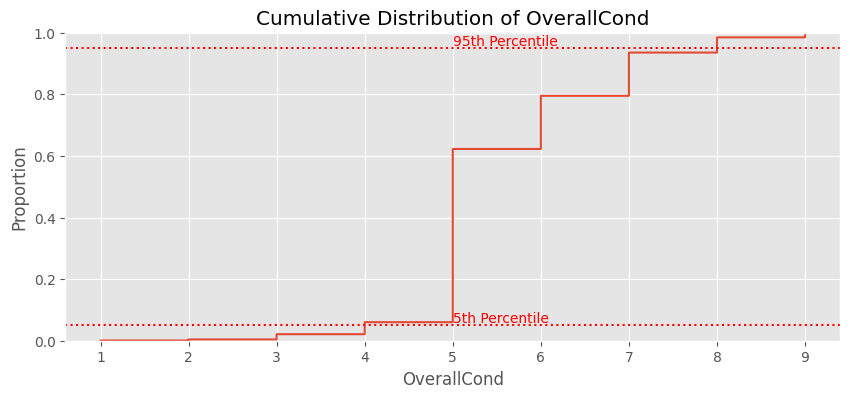

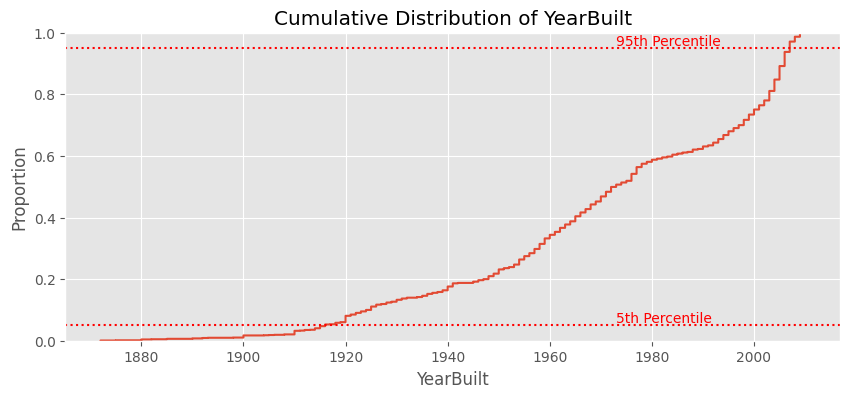

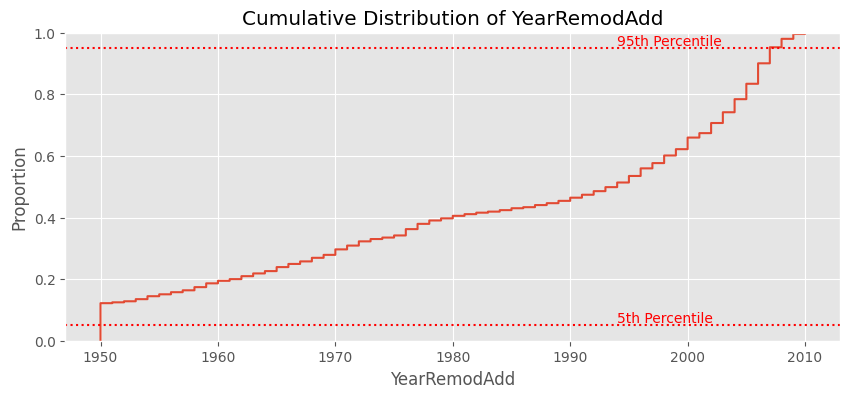

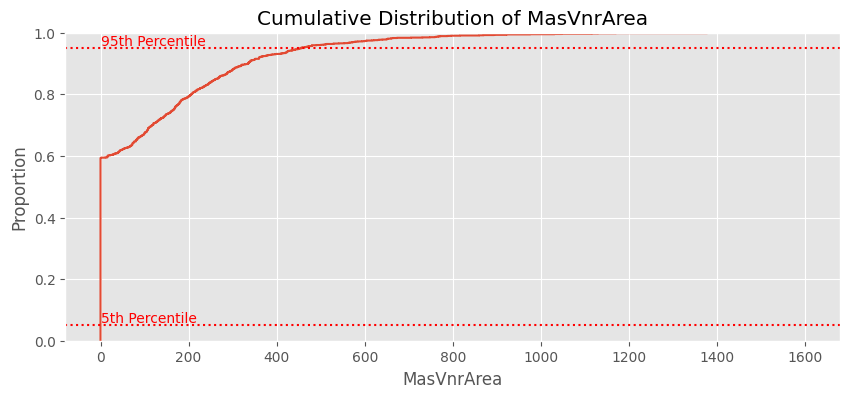

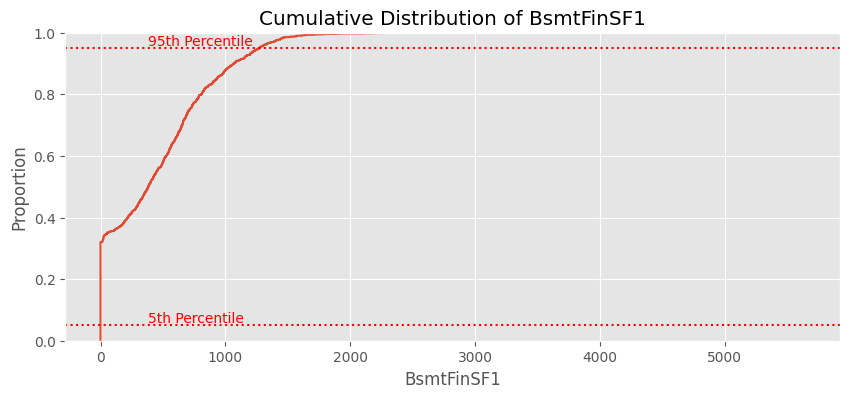

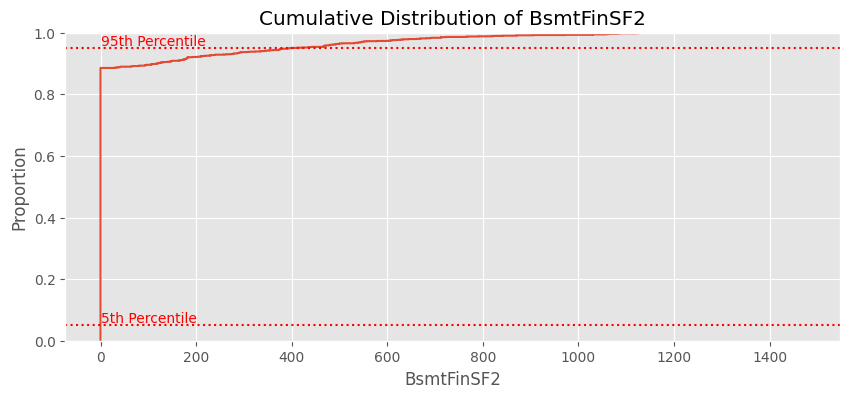

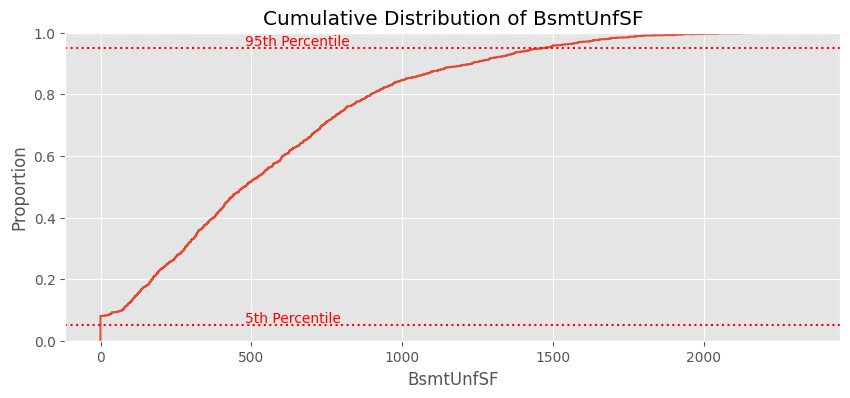

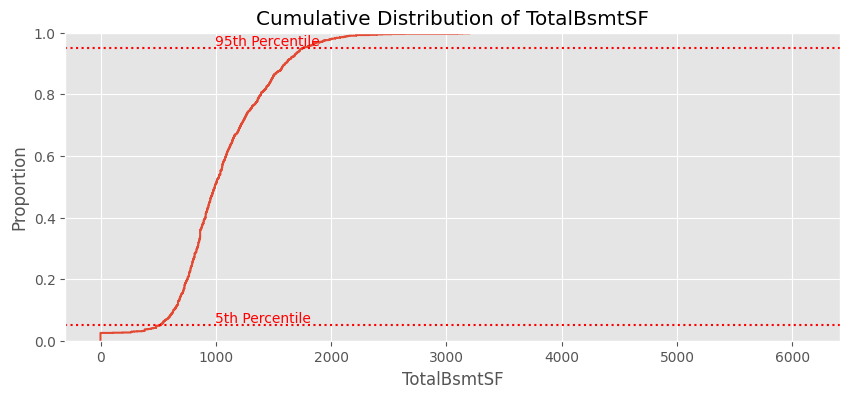

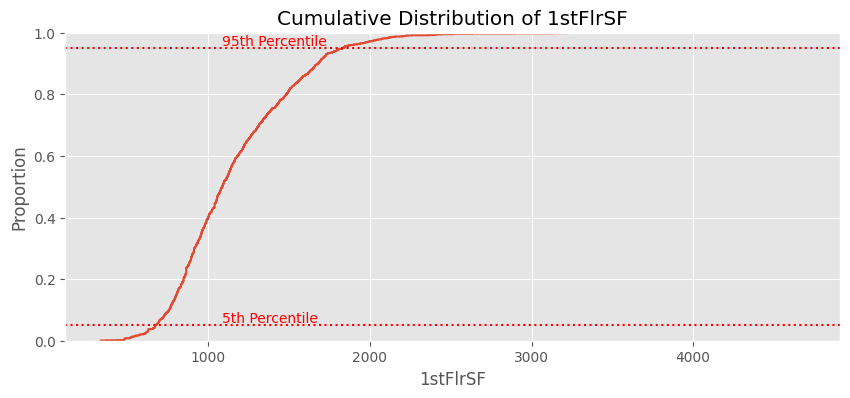

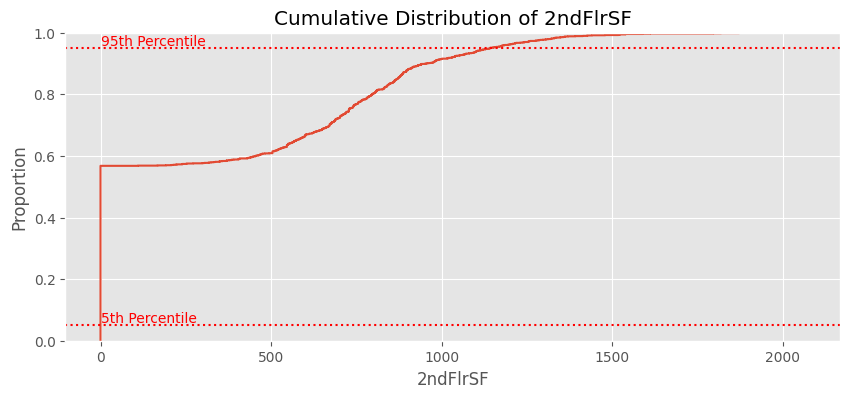

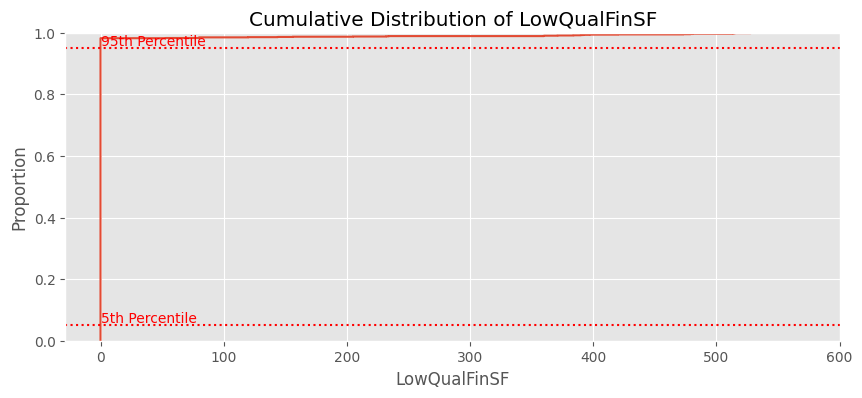

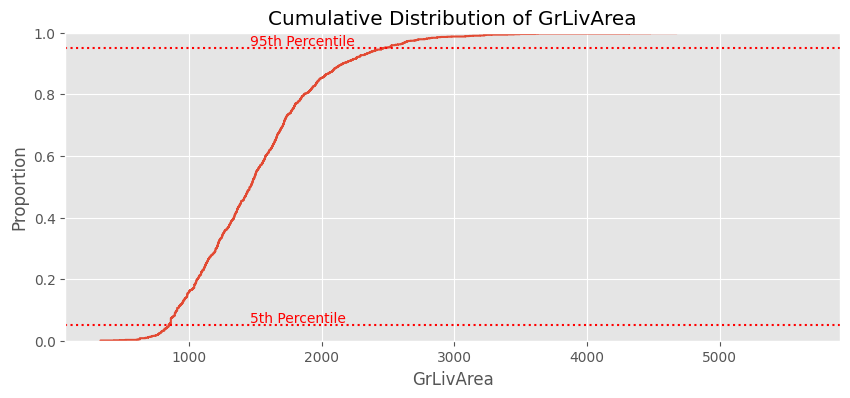

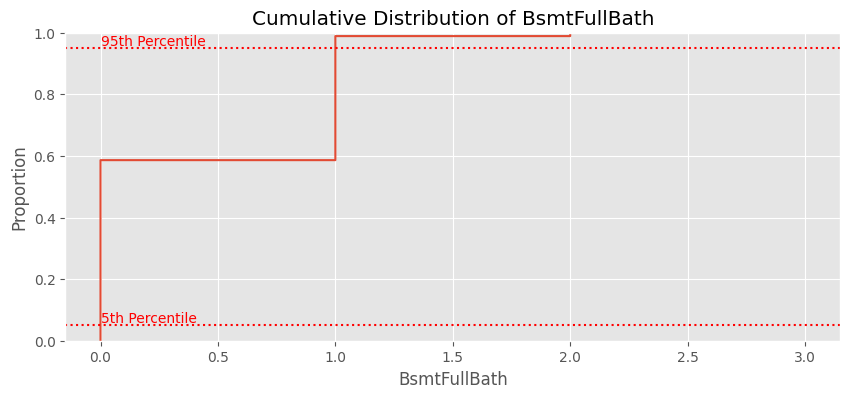

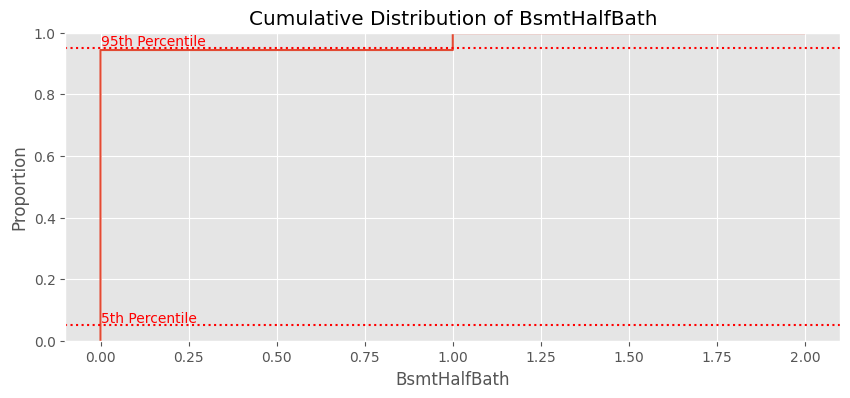

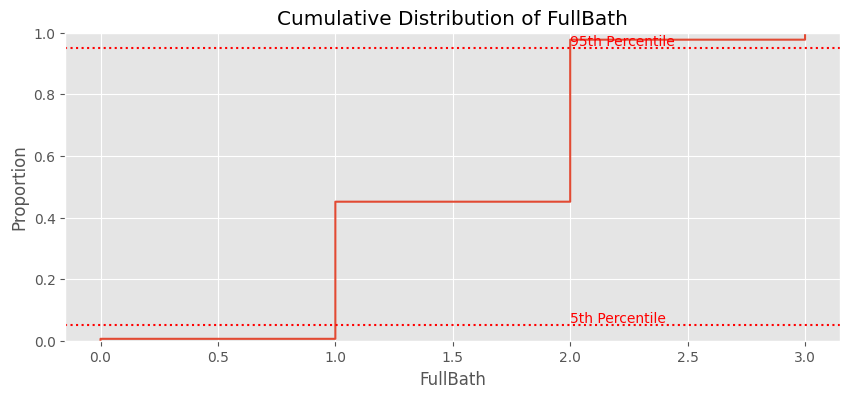

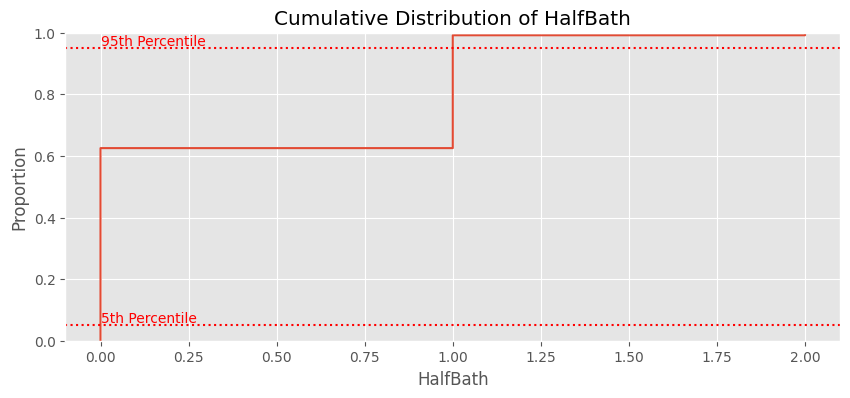

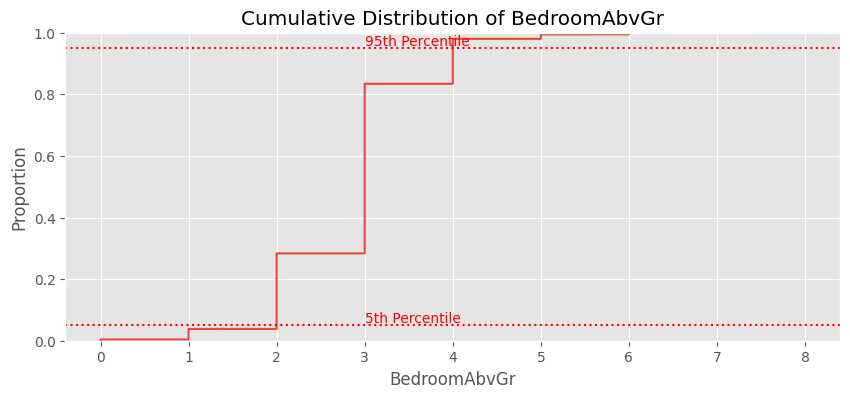

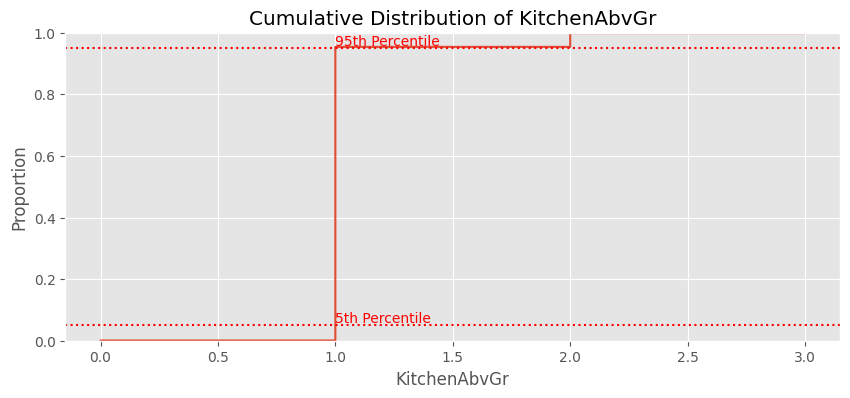

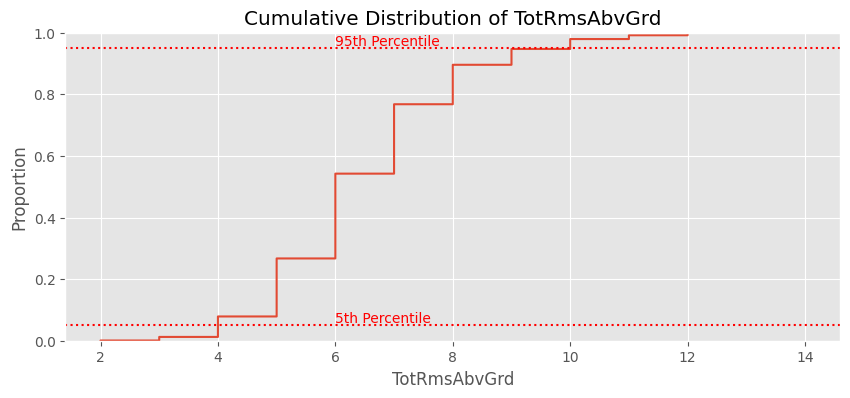

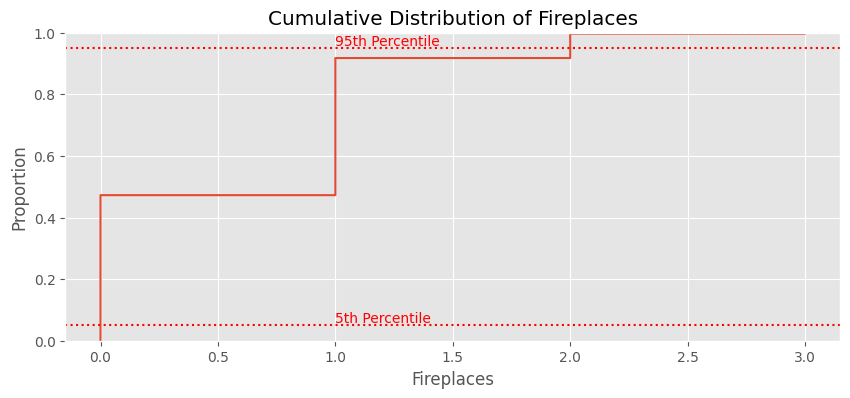

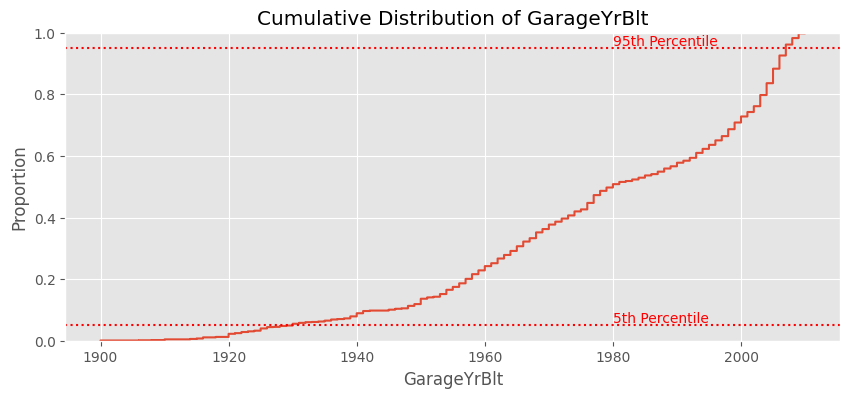

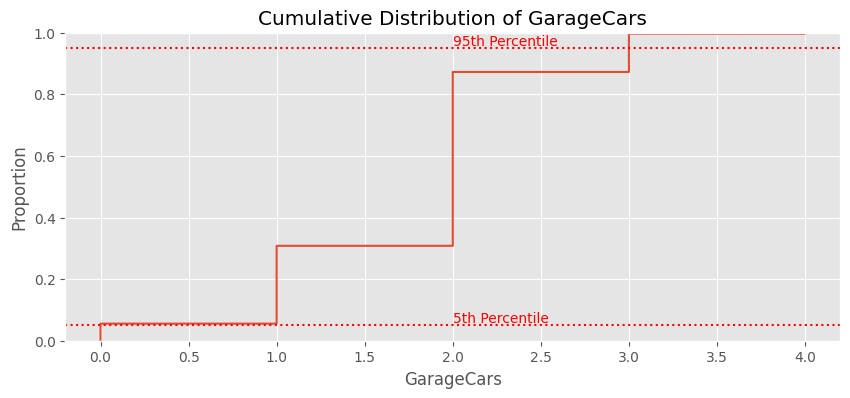

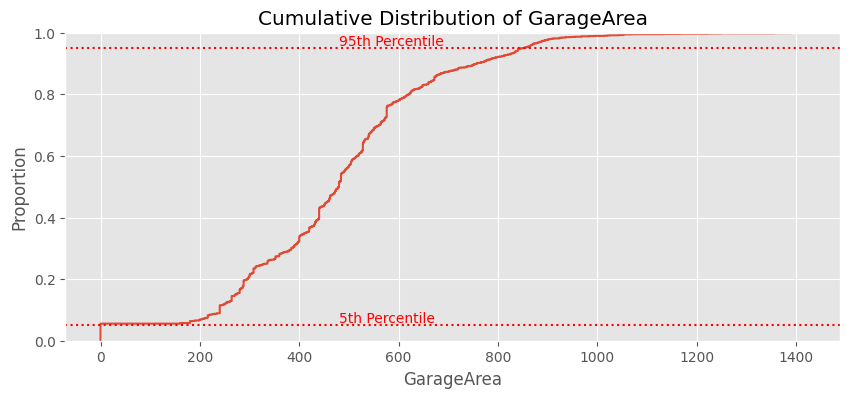

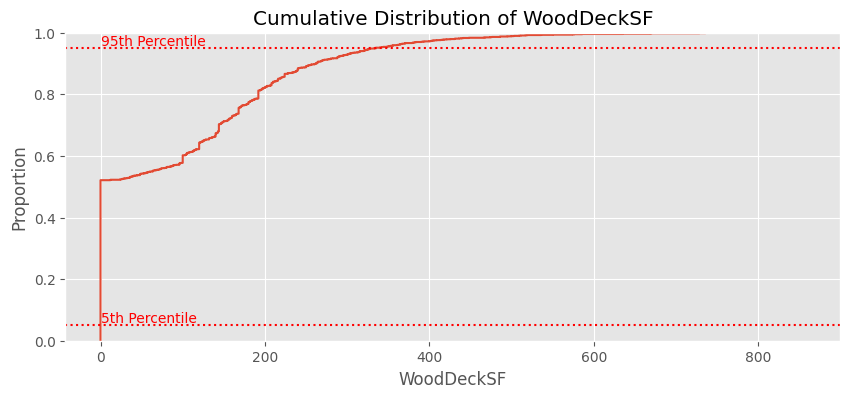

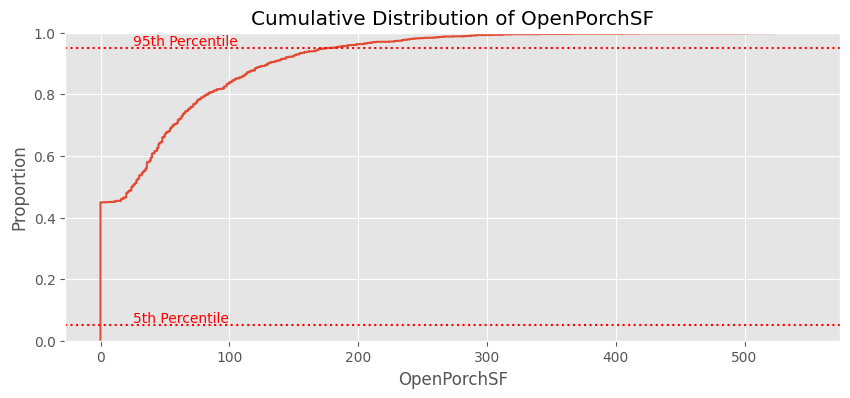

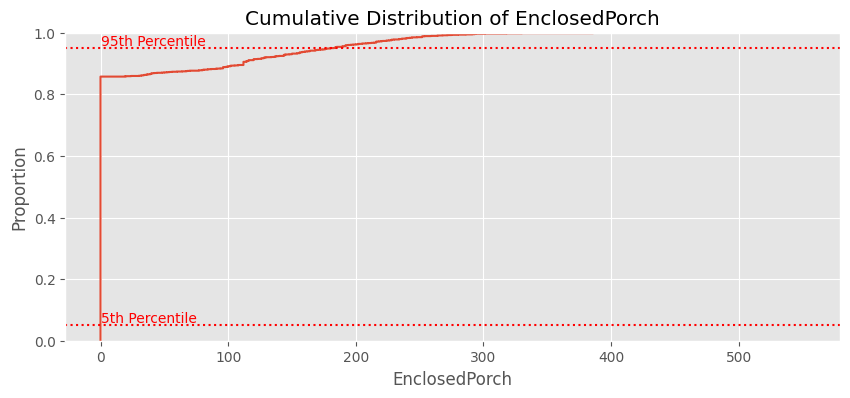

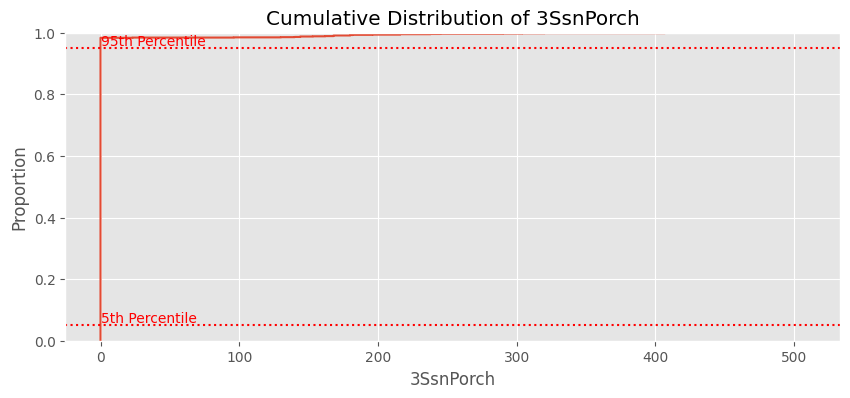

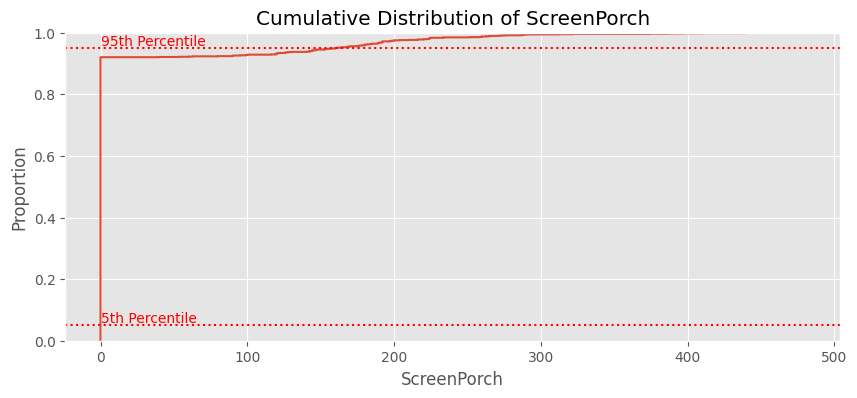

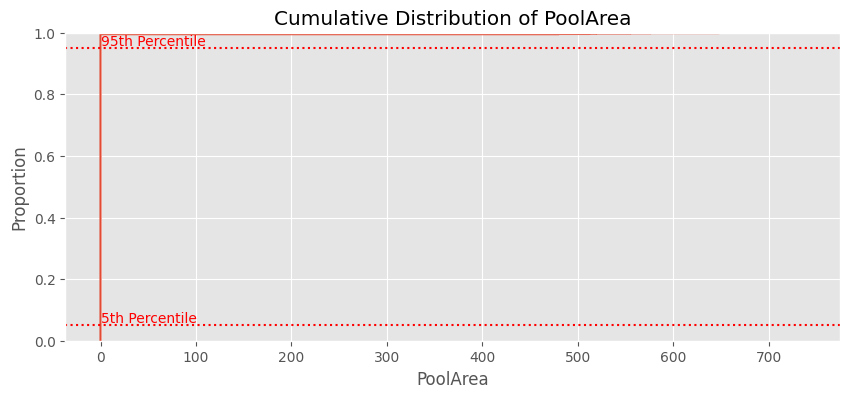

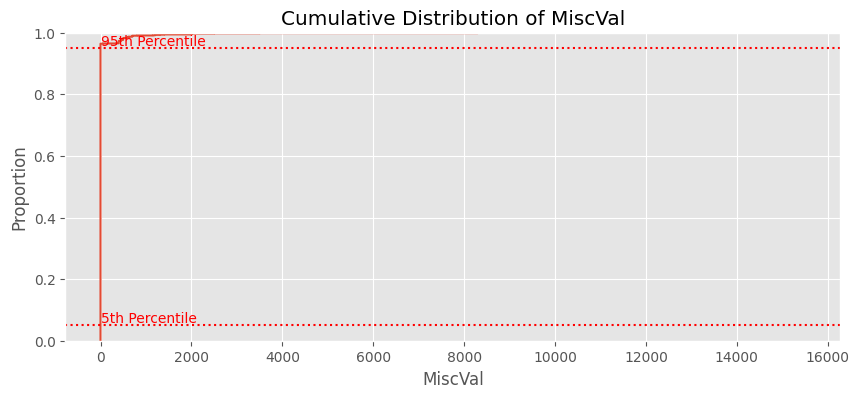

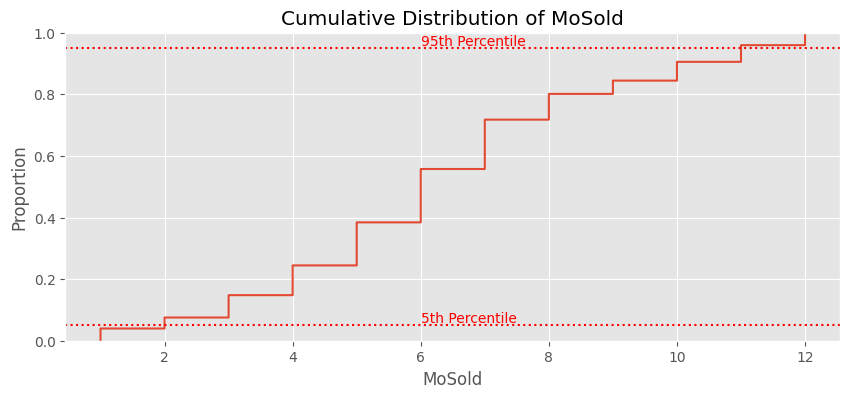

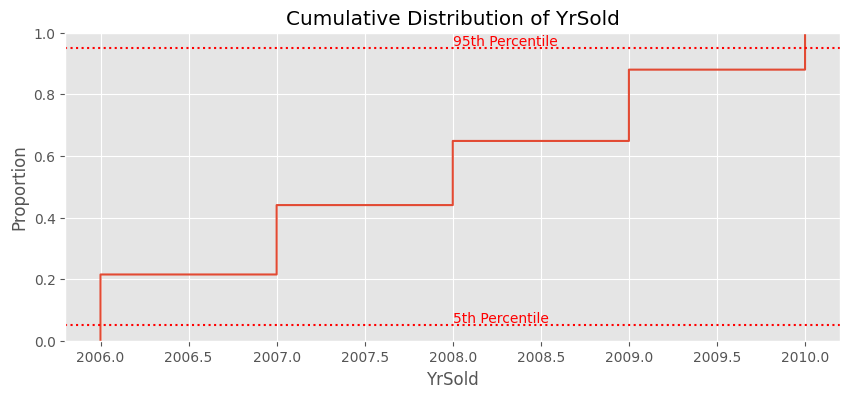

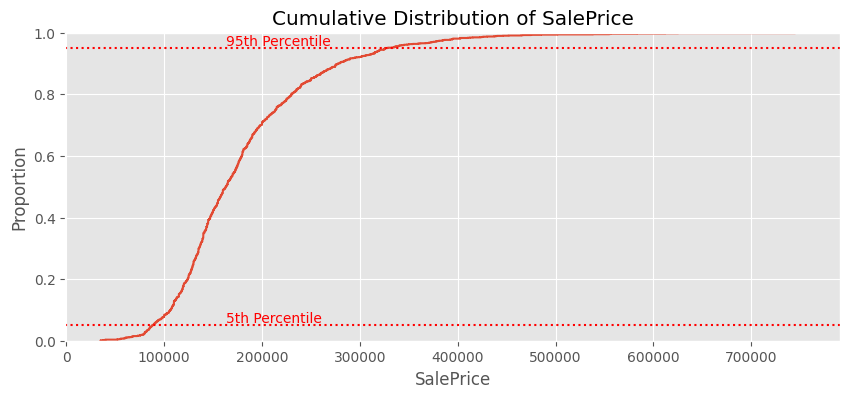

In [9]:

for column in numerical_df:
    plt.figure(figsize=(10, 4))
    sns.ecdfplot(data=numerical_df, x=column)
    
    # Add a line at 95% to see the "cutoff" for the extreme tail
    plt.axhline(0.95, color='red', linestyle=':')
    plt.annotate('95th Percentile', xy=(numerical_df[column].median(), 0.96), color='red')
    plt.axhline(0.05, color='red', linestyle=':')
    plt.annotate('5th Percentile', xy=(numerical_df[column].median(), 0.06), color='red')
    
    plt.title(f'Cumulative Distribution of {column}')
    plt.show()

In [10]:
# # Seeing it with boxplots
# for column in numerical_df:
#     plt.figure(figsize=(16, 4))
#     sns.set_theme(style='whitegrid')
#     sns.boxplot(numerical_df[column], orient='h')
#     plt.xlabel(column)
#     plt.show()

In [11]:
# # With violin plots

# for column in numerical_df:
#     plt.figure(figsize=(12, 6))
    
#     # Violin plot gives the shape; inner='box' adds the mini-boxplot inside
#     sns.violinplot(data=numerical_df, x=column, inner="box", palette="Pastel1")
    
#     # Stripplot adds the "dots" so you can see if outliers are scattered or clustered
#     sns.stripplot(data=numerical_df, x=column, color="black", size=2, alpha=0.3)
    
#     plt.title(f'Raincloud-style Distribution of {column}')
#     plt.show()

**Outlier conclusion:** Whether we need to do somethign about it will depend on what model we want to use later. For example, linear regression is very sensitive to outliers, so we might want to remove them or transform the data. On the other hand, tree-based models like random forests and gradient boosting are more robust to outliers, so we might not need to do anything.

## Check Nan values

Text(0.5, 0, 'Columns')

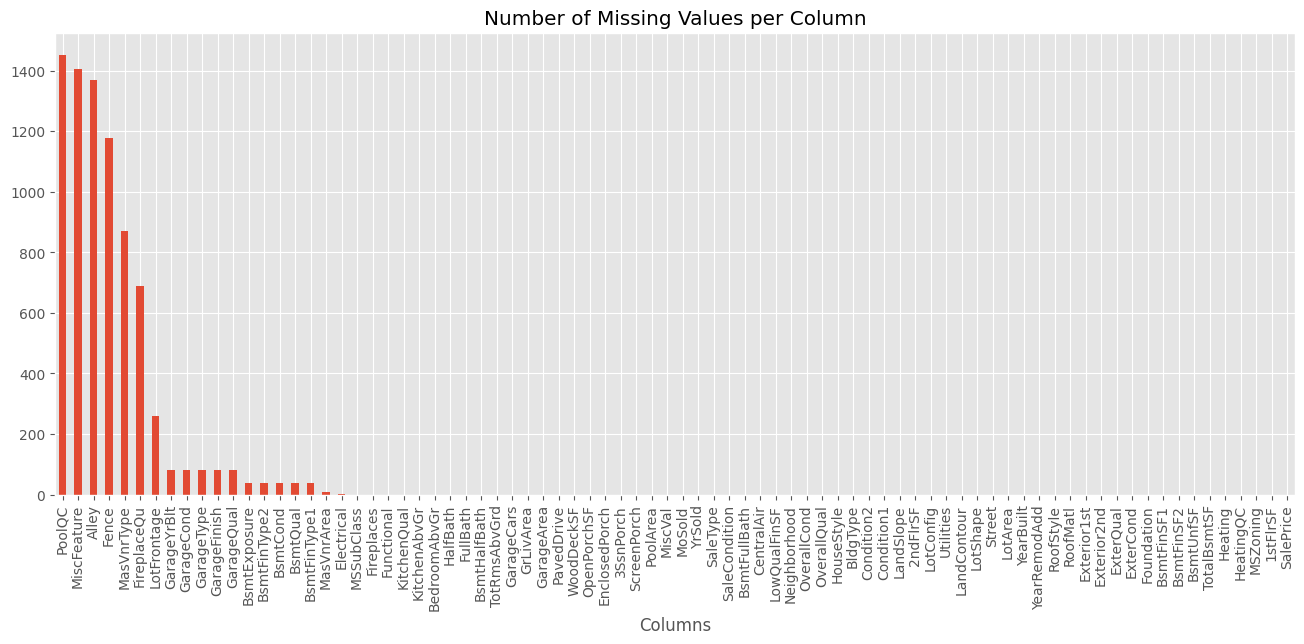

In [12]:
df_train.isna().sum().sort_values(ascending=False).plot(kind='bar', figsize=(16, 6))
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')

## Check correlations

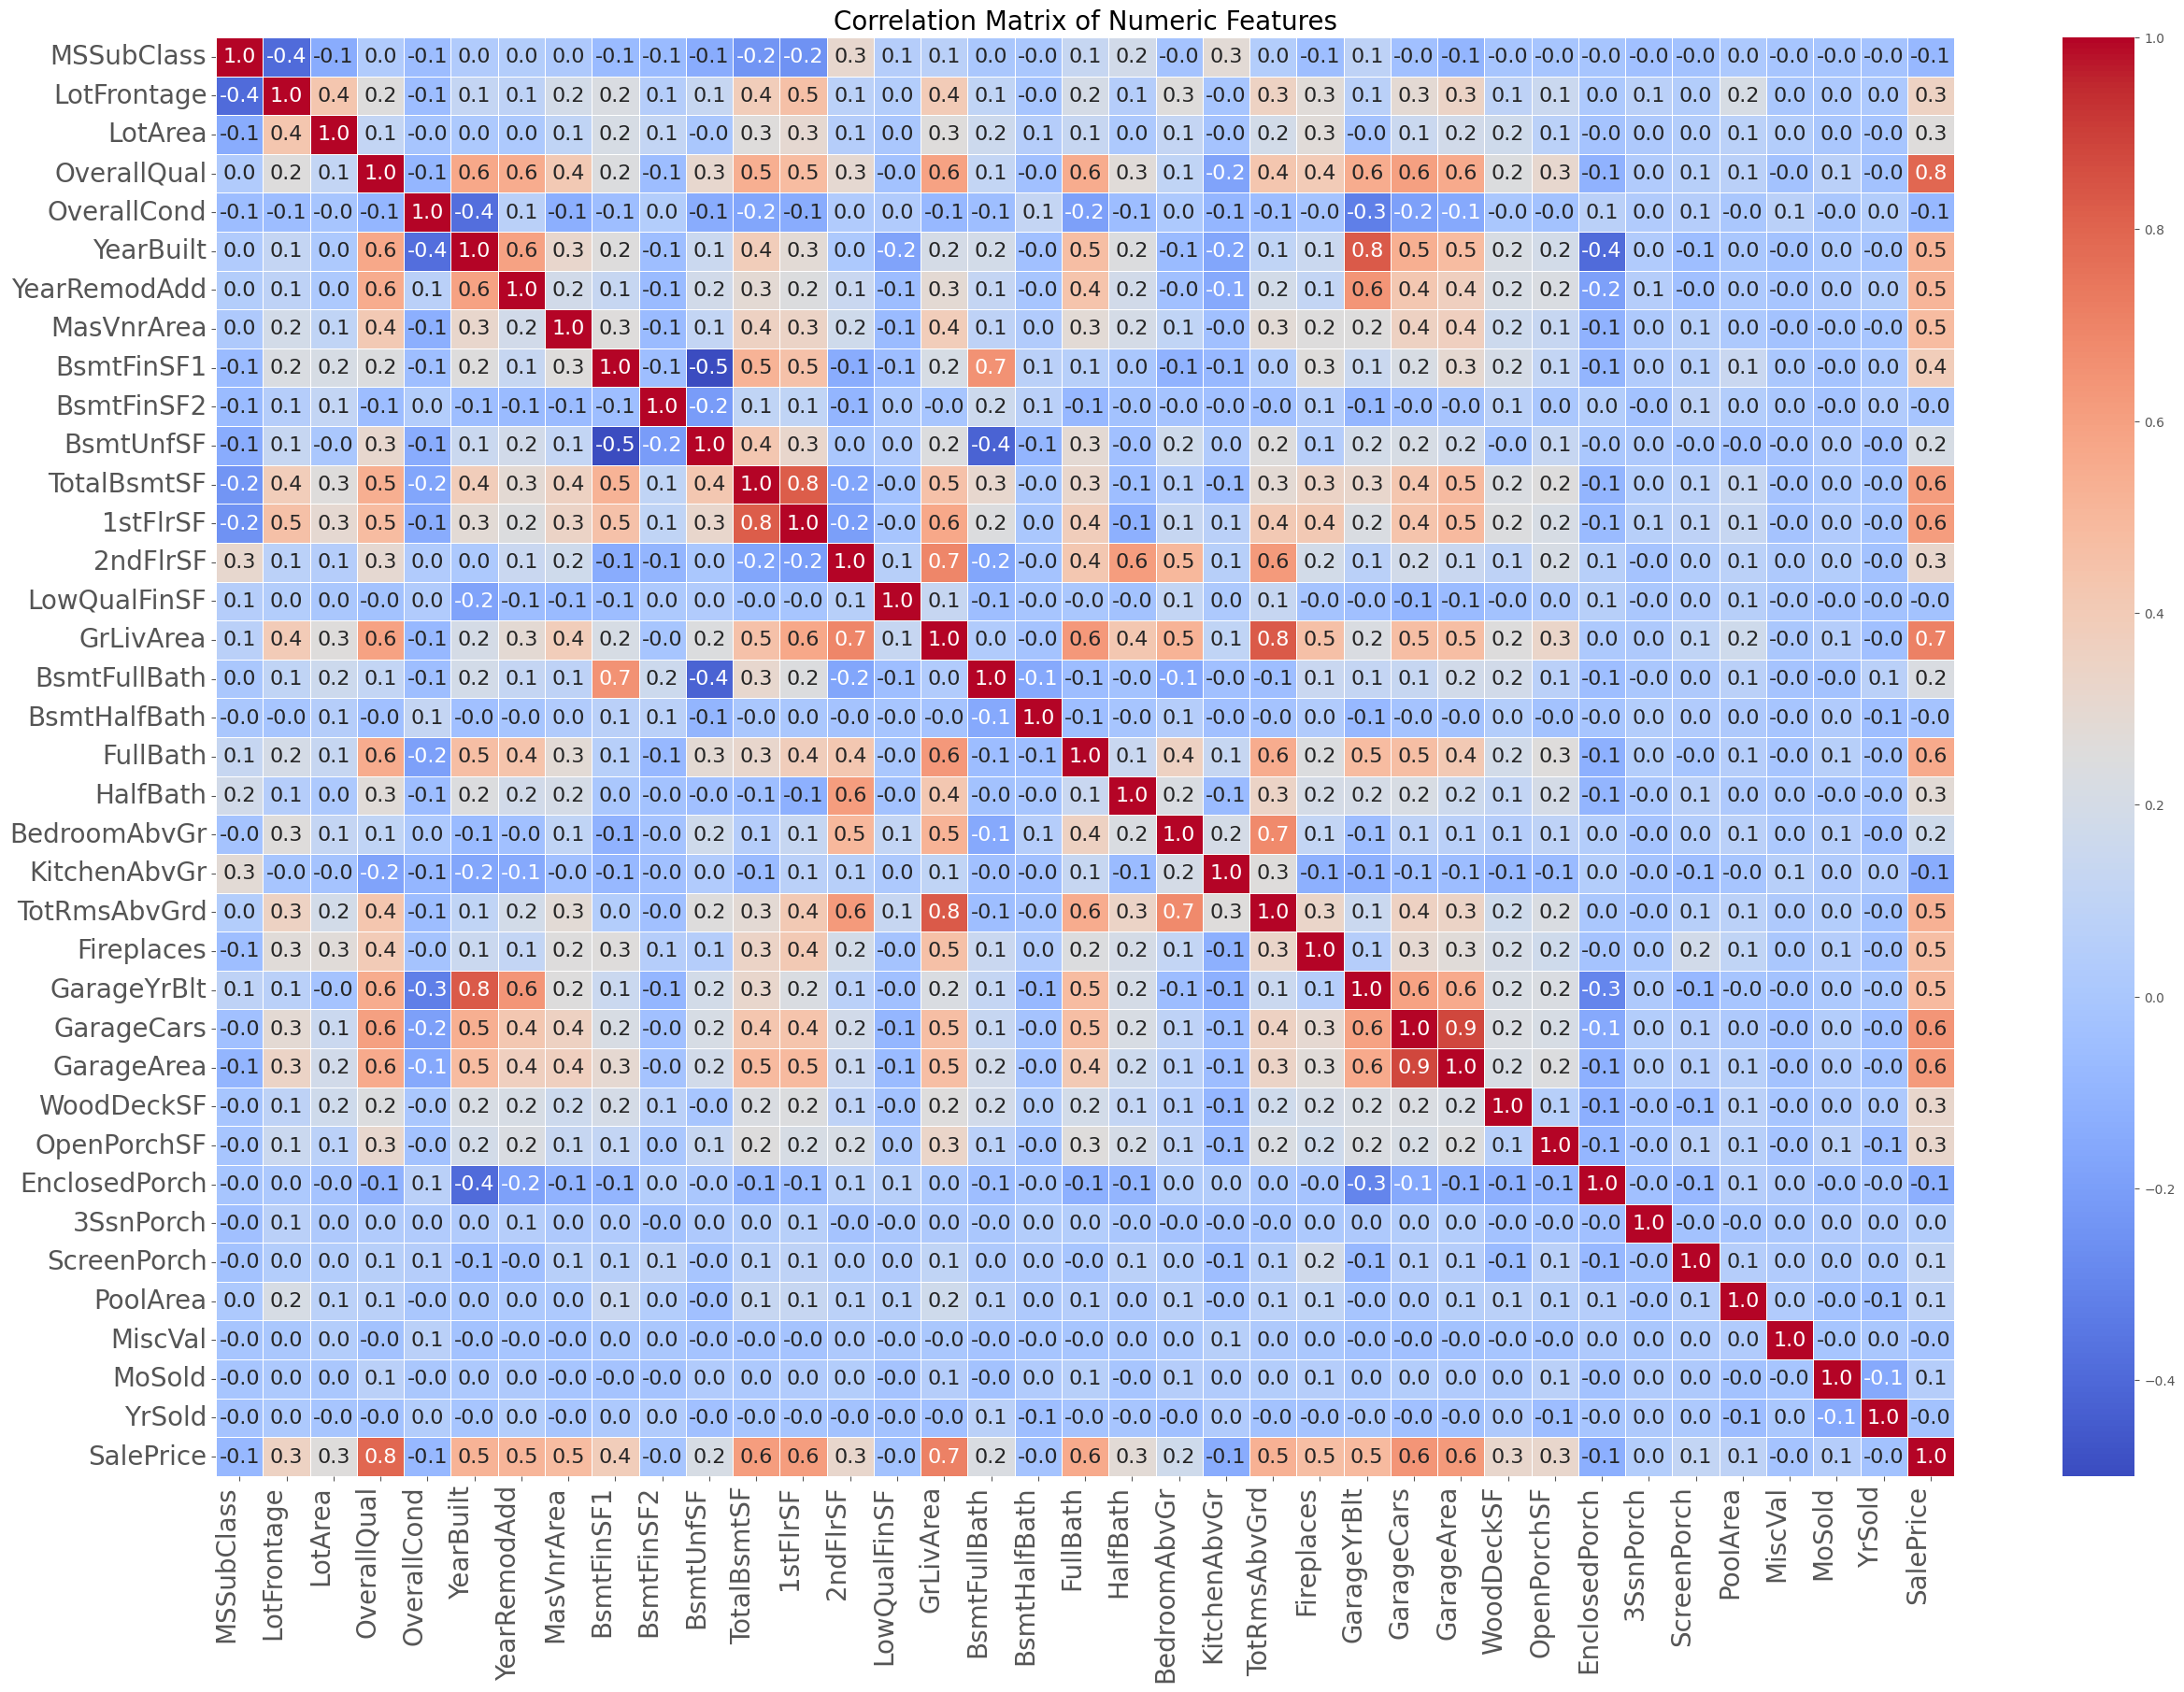

In [13]:
# Look up correlation between numeric features

# Select only numeric columns for calculating the correlation matrix
numeric_df = df_train.select_dtypes(include='number')

# Calculate the correlation matrix
df_corr = numeric_df.corr().round(2)

# Create a heatmap
plt.figure(figsize=(30, 20))
ax = sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt="0.1f", linewidths=0.5, annot_kws={"size": 16})
ax.set_xticks(ax.get_xticks(), df_corr.columns, rotation=90, ha='right', fontsize=20)
ax.set_yticks(ax.get_yticks(), df_corr.columns, rotation=0, va='center', fontsize=20)
plt.title('Correlation Matrix of Numeric Features', fontsize=20)
plt.show()

# Data Cleanup

## Merge df_train and df_inference for simplicity

In [14]:
# Merge the dataframes together
df = pd.concat([df_train, df_inference])

# Reset the index
df.reset_index(drop=True, inplace=True)

df.shape

(2919, 80)

In [15]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,

## Rename Columns

In [16]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [17]:
df = df.rename(columns = {"1stFlrSF" : "FirstFlrSF", "2ndFlrSF" : "SecondFlrSF"}).copy()

## Imput missing data


| Strategy | One-Liner Code | Best Case Scenario |
| :--- | :--- | :--- |
| **Fixed/Constant** | `df[col] = df[col].fillna(0)` | When missing inherently means "None" or "Zero". |
| **Median** | `df[col] = df[col].fillna(df[col].median())` | Numerical data with outliers (skewed distributions). |
| **Mode** | `df[col] = df[col].fillna(df[col].mode()[0])` | Categorical features (Nominal data). |
| **Grouped** | `df[col] = df.groupby('Key')[col].transform(lambda x: x.fillna(x.median()))` | Values that depend on a context (e.g., Neighborhood). |
| **Forward Fill** | `df[col] = df[col].ffill()` | Time-series or sequentially ordered data. |
| **Indicator** | `df['col_is_missing'] = df[col].isnull().astype(int)` | When the "fact of being missing" is a predictive signal. |

In [18]:
df.isna().sum().sort_values(ascending=False).head(36)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
SalePrice       1459
FireplaceQu     1420
LotFrontage      486
GarageFinish     159
GarageQual       159
GarageCond       159
GarageYrBlt      159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Utilities          2
BsmtFullBath       2
Functional         2
Exterior2nd        1
Exterior1st        1
GarageArea         1
GarageCars         1
SaleType           1
KitchenQual        1
BsmtFinSF1         1
Electrical         1
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
TotRmsAbvGrd       0
dtype: int64

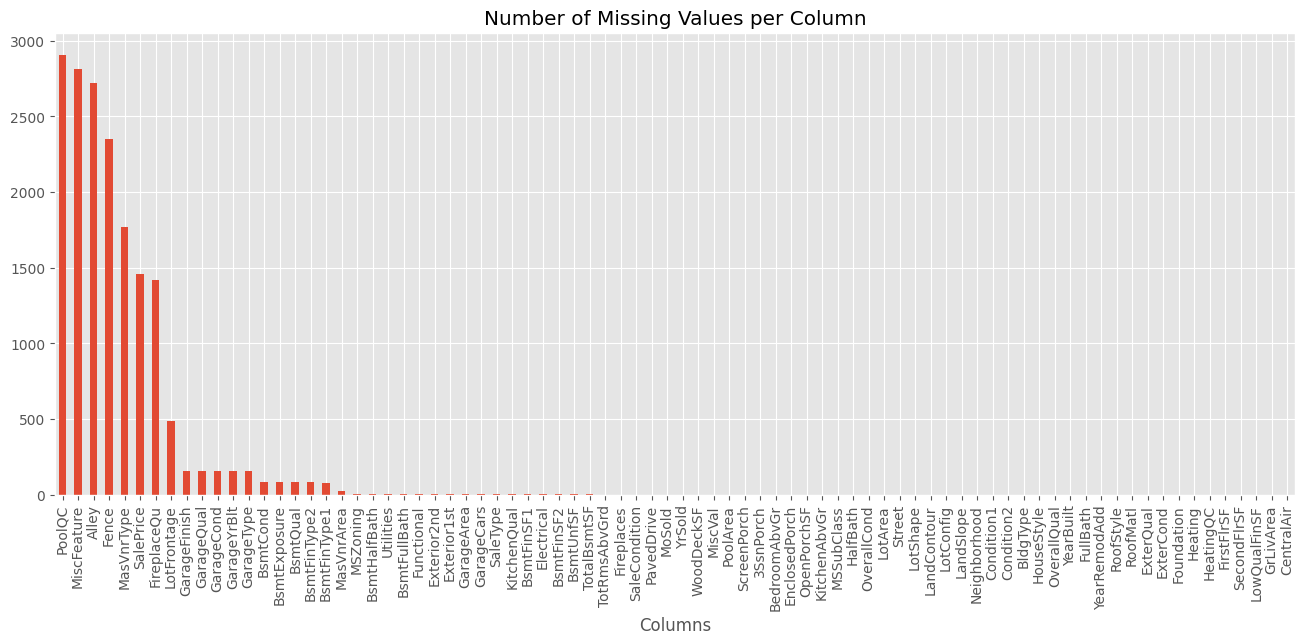

In [19]:
df.isna().sum().sort_values(ascending=False).plot(kind='bar', figsize=(16, 6))
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.show()



### Dealing with the missing values

In [20]:
# Dealing with PoolQC
df["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    2909
Ex        4
Gd        4
Fa        2
Name: count, dtype: int64

In [21]:
df["PoolQC"] = df["PoolQC"].fillna("None")
df["PoolQC"].value_counts(dropna=False)

PoolQC
None    2909
Ex         4
Gd         4
Fa         2
Name: count, dtype: int64

In [22]:
# Dealing with MiscFeature
df["MiscFeature"].value_counts(dropna=False) 


MiscFeature
NaN     2814
Shed      95
Gar2       5
Othr       4
TenC       1
Name: count, dtype: int64

In [23]:
df["MiscFeature"] = df["MiscFeature"].fillna("None")
df["MiscFeature"].value_counts(dropna=False)

MiscFeature
None    2814
Shed      95
Gar2       5
Othr       4
TenC       1
Name: count, dtype: int64

In [24]:
# Dealing with Alley
df["Alley"].value_counts(dropna=False) 


Alley
NaN     2721
Grvl     120
Pave      78
Name: count, dtype: int64

In [25]:
df["Alley"] = df["Alley"].fillna("None")
df["Alley"].value_counts(dropna=False)

Alley
None    2721
Grvl     120
Pave      78
Name: count, dtype: int64

In [26]:
# Dealing with Fence
df["Fence"].value_counts(dropna=False) 


Fence
NaN      2348
MnPrv     329
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64

In [27]:
df["Fence"] = df["Fence"].fillna("None")
df["Fence"].value_counts(dropna=False)

Fence
None     2348
MnPrv     329
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64

In [28]:
# Dealing with MasVnrType
df["MasVnrType"].value_counts(dropna=False) 


MasVnrType
NaN        1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64

In [29]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
None       1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64

In [30]:
# Dealing with FireplaceQu
df["FireplaceQu"].value_counts(dropna=False) 

FireplaceQu
NaN    1420
Gd      744
TA      592
Fa       74
Po       46
Ex       43
Name: count, dtype: int64

In [31]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")
df["FireplaceQu"].value_counts(dropna=False)

FireplaceQu
None    1420
Gd       744
TA       592
Fa        74
Po        46
Ex        43
Name: count, dtype: int64

In [32]:
# Dealing with LotFrontage
df["LotFrontage"].value_counts(dropna=False) 


LotFrontage
NaN      486
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
111.0      1
138.0      1
182.0      1
168.0      1
133.0      1
Name: count, Length: 129, dtype: int64

In [33]:
df["LotFrontage"] = df["LotFrontage"].fillna(df_train["LotFrontage"].median()) # importantly, here i am just using the df_train median
df["LotFrontage"].value_counts(dropna=False)

LotFrontage
69.0     506
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
152.0      1
138.0      1
182.0      1
168.0      1
133.0      1
Name: count, Length: 128, dtype: int64

In [34]:
# Dealing with GarageFinish
df["GarageFinish"].value_counts(dropna=False) 


GarageFinish
Unf    1230
RFn     811
Fin     719
NaN     159
Name: count, dtype: int64

In [35]:
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageFinish"].value_counts(dropna=False)

GarageFinish
Unf     1230
RFn      811
Fin      719
None     159
Name: count, dtype: int64

In [36]:
# Dealing with GarageQual
df["GarageQual"].value_counts(dropna=False) 


GarageQual
TA     2604
NaN     159
Fa      124
Gd       24
Po        5
Ex        3
Name: count, dtype: int64

In [37]:
df["GarageQual"] = df["GarageQual"].fillna("None")
df["GarageQual"].value_counts(dropna=False)

GarageQual
TA      2604
None     159
Fa       124
Gd        24
Po         5
Ex         3
Name: count, dtype: int64

In [38]:
# Dealing with GarageCond
df["GarageCond"].value_counts(dropna=False) 


GarageCond
TA     2654
NaN     159
Fa       74
Gd       15
Po       14
Ex        3
Name: count, dtype: int64

In [39]:
df["GarageCond"] = df["GarageCond"].fillna("None")
df["GarageCond"].value_counts(dropna=False)

GarageCond
TA      2654
None     159
Fa        74
Gd        15
Po        14
Ex         3
Name: count, dtype: int64

In [40]:
# Dealing with GarageYrBlt
df["GarageYrBlt"].value_counts(dropna=False) 


GarageYrBlt
NaN       159
2005.0    142
2007.0    115
2006.0    115
2004.0     99
         ... 
1908.0      1
1896.0      1
1933.0      1
1906.0      1
1919.0      1
Name: count, Length: 104, dtype: int64

In [41]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df_train["GarageYrBlt"].median()) # importantly, here i am just using the df_train median
df["GarageYrBlt"].value_counts(dropna=False)

GarageYrBlt
1980.0    191
2005.0    142
2006.0    115
2007.0    115
2004.0     99
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 103, dtype: int64

In [42]:
#replace error
df["GarageYrBlt"].min(), df["GarageYrBlt"].max()


(1895.0, 2207.0)

In [43]:
df['GarageYrBlt'] = df['GarageYrBlt'].replace(2207, 2007)

In [44]:
# Dealing with GarageType
df["GarageType"].value_counts(dropna=False) 


GarageType
Attchd     1723
Detchd      779
BuiltIn     186
NaN         157
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

In [45]:
df["GarageType"] = df["GarageType"].fillna("None")
df["GarageType"].value_counts(dropna=False)

GarageType
Attchd     1723
Detchd      779
BuiltIn     186
None        157
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

In [46]:
# Dealing with BsmtCond
df["BsmtCond"].value_counts(dropna=False) 


BsmtCond
TA     2606
Gd      122
Fa      104
NaN      82
Po        5
Name: count, dtype: int64

In [47]:
df["BsmtCond"] = df["BsmtCond"].fillna("None")
df["BsmtCond"].value_counts(dropna=False)

BsmtCond
TA      2606
Gd       122
Fa       104
None      82
Po         5
Name: count, dtype: int64

In [48]:
# Dealing with BsmtExposure
df["BsmtExposure"].value_counts(dropna=False) 


BsmtExposure
No     1904
Av      418
Gd      276
Mn      239
NaN      82
Name: count, dtype: int64

In [49]:
df["BsmtExposure"] = df["BsmtExposure"].fillna("None")
df["BsmtExposure"].value_counts(dropna=False)

BsmtExposure
No      1904
Av       418
Gd       276
Mn       239
None      82
Name: count, dtype: int64

In [50]:
# Dealing with BsmtQual
df["BsmtQual"].value_counts(dropna=False) 


BsmtQual
TA     1283
Gd     1209
Ex      258
Fa       88
NaN      81
Name: count, dtype: int64

In [51]:
df["BsmtQual"] = df["BsmtQual"].fillna("None")
df["BsmtQual"].value_counts(dropna=False)

BsmtQual
TA      1283
Gd      1209
Ex       258
Fa        88
None      81
Name: count, dtype: int64

In [52]:
# Dealing with BsmtFinType2
df["BsmtFinType2"].value_counts(dropna=False) 


BsmtFinType2
Unf    2493
Rec     105
LwQ      87
NaN      80
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64

In [53]:
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("None")
df["BsmtFinType2"].value_counts(dropna=False)

BsmtFinType2
Unf     2493
Rec      105
LwQ       87
None      80
BLQ       68
ALQ       52
GLQ       34
Name: count, dtype: int64

In [54]:
# Dealing with BsmtFinType1
df["BsmtFinType1"].value_counts(dropna=False) 


BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
NaN     79
Name: count, dtype: int64

In [55]:
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("None")
df["BsmtFinType1"].value_counts(dropna=False)

BsmtFinType1
Unf     851
GLQ     849
ALQ     429
Rec     288
BLQ     269
LwQ     154
None     79
Name: count, dtype: int64

In [56]:
# Dealing with MasVnrArea
df["MasVnrArea"].value_counts(dropna=False) 


MasVnrArea
0.0      1738
NaN        23
120.0      15
176.0      13
200.0      13
         ... 
788.0       1
796.0       1
391.0       1
604.0       1
382.0       1
Name: count, Length: 445, dtype: int64

In [57]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["MasVnrArea"].value_counts(dropna=False)

MasVnrArea
0.0      1761
120.0      15
176.0      13
200.0      13
216.0      12
         ... 
137.0       1
274.0       1
415.0       1
760.0       1
382.0       1
Name: count, Length: 444, dtype: int64

In [58]:
# Dealing with MSZoning
df["MSZoning"].value_counts(dropna=False) 


MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
NaN           4
Name: count, dtype: int64

In [59]:
df["MSZoning"] = df["MSZoning"].fillna("None")
df["MSZoning"].value_counts(dropna=False)

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
None          4
Name: count, dtype: int64

In [60]:
# Dealing with BsmtHalfBath
df["BsmtHalfBath"].value_counts(dropna=False) 


BsmtHalfBath
0.0    2742
1.0     171
2.0       4
NaN       2
Name: count, dtype: int64

In [61]:
df["BsmtHalfBath"] = df["BsmtHalfBath"].fillna(0)
df["BsmtHalfBath"].value_counts()

BsmtHalfBath
0.0    2744
1.0     171
2.0       4
Name: count, dtype: int64

In [62]:
# # If you do something wrong
# df["BsmtHalfBath"].replace("None", 0, inplace=True)
# df["BsmtHalfBath"].value_counts()

In [63]:
# Dealing with Utilities
df["Utilities"].value_counts(dropna=False) 


Utilities
AllPub    2916
NaN          2
NoSeWa       1
Name: count, dtype: int64

In [64]:
df["Utilities"] = df["Utilities"].fillna("AllPub")
df["Utilities"].value_counts()

Utilities
AllPub    2918
NoSeWa       1
Name: count, dtype: int64

In [65]:
# # If you do something wrong
# df["Utilities"].replace("None", "AllPub", inplace=True)
# df["Utilities"].value_counts()

In [66]:
# Dealing with BsmtFullBath
df["BsmtFullBath"].value_counts(dropna=False) 


BsmtFullBath
0.0    1705
1.0    1172
2.0      38
3.0       2
NaN       2
Name: count, dtype: int64

In [67]:
df["BsmtFullBath"] = df["BsmtFullBath"].fillna(0)
df["BsmtFullBath"].value_counts()

BsmtFullBath
0.0    1707
1.0    1172
2.0      38
3.0       2
Name: count, dtype: int64

In [68]:
# Dealing with Functional
df["Functional"].value_counts(dropna=False) 


Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
NaN        2
Name: count, dtype: int64

In [69]:
df["Functional"] = df["Functional"].fillna("Typ")
df["Functional"].value_counts(dropna=False)

Functional
Typ     2719
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [70]:
# Dealing with Exterior2nd
df["Exterior2nd"].value_counts(dropna=False) 


Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
Stucco       47
BrkFace      47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
NaN           1
Name: count, dtype: int64

In [71]:
df["Exterior2nd"] = df["Exterior2nd"].fillna("None")
df["Exterior2nd"].value_counts(dropna=False)

Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
Stucco       47
BrkFace      47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
None          1
Name: count, dtype: int64

In [72]:
# Dealing with Exterior1st
df["Exterior1st"].value_counts(dropna=False) 


Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
NaN           1
Name: count, dtype: int64

In [73]:
df["Exterior1st"] = df["Exterior1st"].fillna("None")
df["Exterior1st"].value_counts(dropna=False)

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
None          1
Name: count, dtype: int64

In [74]:
# Dealing with GarageArea
df["GarageArea"].value_counts(dropna=False) 


GarageArea
0.0       157
576.0      97
440.0      96
240.0      69
484.0      68
         ... 
459.0       1
954.0       1
1014.0      1
753.0       1
272.0       1
Name: count, Length: 604, dtype: int64

In [75]:
df["GarageArea"] = df["GarageArea"].fillna(0)
df["GarageArea"].value_counts(dropna=False)

GarageArea
0.0       158
576.0      97
440.0      96
240.0      69
484.0      68
         ... 
872.0       1
923.0       1
192.0       1
1025.0      1
272.0       1
Name: count, Length: 603, dtype: int64

In [76]:
# Dealing with GarageCars
df["GarageCars"].value_counts(dropna=False) 


GarageCars
2.0    1594
1.0     776
3.0     374
0.0     157
4.0      16
5.0       1
NaN       1
Name: count, dtype: int64

In [77]:
df["GarageCars"] = df["GarageCars"].fillna(0)
df["GarageCars"].value_counts(dropna=False)

GarageCars
2.0    1594
1.0     776
3.0     374
0.0     158
4.0      16
5.0       1
Name: count, dtype: int64

In [78]:
# Dealing with SaleType
df["SaleType"].value_counts(dropna=False) 


SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
NaN         1
Name: count, dtype: int64

In [79]:
df["SaleType"] = df["SaleType"].fillna("None")
df["SaleType"].value_counts(dropna=False)

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
None        1
Name: count, dtype: int64

In [80]:
# Dealing with KitchenQual
df["KitchenQual"].value_counts(dropna=False) 


KitchenQual
TA     1492
Gd     1151
Ex      205
Fa       70
NaN       1
Name: count, dtype: int64

In [81]:
df["KitchenQual"] = df["KitchenQual"].fillna("TA")
df["KitchenQual"].value_counts(dropna=False)

KitchenQual
TA    1493
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [82]:
# Dealing with BsmtFinSF1
df["BsmtFinSF1"].value_counts(dropna=False) 


BsmtFinSF1
0.0       929
24.0       27
16.0       14
300.0       9
20.0        8
         ... 
383.0       1
1085.0      1
900.0       1
1022.0      1
337.0       1
Name: count, Length: 992, dtype: int64

In [83]:
df["BsmtFinSF1"] = df["BsmtFinSF1"].fillna(0)
df["BsmtFinSF1"].value_counts(dropna=False)

BsmtFinSF1
0.0       930
24.0       27
16.0       14
300.0       9
288.0       8
         ... 
383.0       1
1085.0      1
900.0       1
1022.0      1
337.0       1
Name: count, Length: 991, dtype: int64

In [84]:
# Dealing with Electrical
df["Electrical"].value_counts(dropna=False) 


Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
NaN         1
Name: count, dtype: int64

In [85]:
df["Electrical"] = df["Electrical"].fillna("SBrkr")
df["Electrical"].value_counts(dropna=False)

Electrical
SBrkr    2672
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [86]:
# Dealing with BsmtFinSF2
df["BsmtFinSF2"].value_counts(dropna=False) 


BsmtFinSF2
0.0       2571
180.0        5
294.0        5
483.0        3
168.0        3
          ... 
600.0        1
211.0        1
1031.0       1
438.0        1
297.0        1
Name: count, Length: 273, dtype: int64

In [87]:
df["BsmtFinSF2"] = df["BsmtFinSF2"].fillna(0)
df["BsmtFinSF2"].value_counts(dropna=False)

BsmtFinSF2
0.0       2572
180.0        5
294.0        5
435.0        3
483.0        3
          ... 
600.0        1
211.0        1
1031.0       1
438.0        1
297.0        1
Name: count, Length: 272, dtype: int64

In [88]:
# Dealing with BsmtUnfSF
df["BsmtUnfSF"].value_counts(dropna=False) 


BsmtUnfSF
0.0       241
384.0      19
728.0      14
672.0      13
600.0      12
         ... 
574.0       1
1502.0      1
568.0       1
26.0        1
1503.0      1
Name: count, Length: 1136, dtype: int64

In [89]:
df["BsmtUnfSF"] = df["BsmtUnfSF"].fillna(0)
df["BsmtUnfSF"].value_counts(dropna=False)

BsmtUnfSF
0.0       242
384.0      19
728.0      14
672.0      13
600.0      12
         ... 
257.0       1
1217.0      1
539.0       1
39.0        1
1503.0      1
Name: count, Length: 1135, dtype: int64

In [90]:
# Dealing with TotalBsmtSF
df["TotalBsmtSF"].value_counts(dropna=False) 


TotalBsmtSF
0.0       78
864.0     74
672.0     29
912.0     26
1040.0    25
          ..
1571.0     1
2633.0     1
757.0      1
873.0      1
1381.0     1
Name: count, Length: 1059, dtype: int64

In [91]:
df["TotalBsmtSF"] = df["TotalBsmtSF"].fillna(0)
df["TotalBsmtSF"].value_counts(dropna=False)

TotalBsmtSF
0.0       79
864.0     74
672.0     29
912.0     26
1040.0    25
          ..
1571.0     1
2633.0     1
757.0      1
873.0      1
1381.0     1
Name: count, Length: 1058, dtype: int64

### Outcome

In [92]:
df.isna().sum().sort_values(ascending=False).head(36)

SalePrice        1459
MSZoning            0
GarageYrBlt         0
GarageType          0
FireplaceQu         0
Fireplaces          0
Functional          0
TotRmsAbvGrd        0
KitchenQual         0
KitchenAbvGr        0
BedroomAbvGr        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
BsmtFullBath        0
GrLivArea           0
LowQualFinSF        0
SecondFlrSF         0
FirstFlrSF          0
GarageFinish        0
GarageCars          0
GarageArea          0
PoolQC              0
SaleCondition       0
SaleType            0
YrSold              0
MoSold              0
MiscVal             0
MiscFeature         0
Fence               0
PoolArea            0
GarageQual          0
ScreenPorch         0
3SsnPorch           0
EnclosedPorch       0
OpenPorchSF         0
dtype: int64

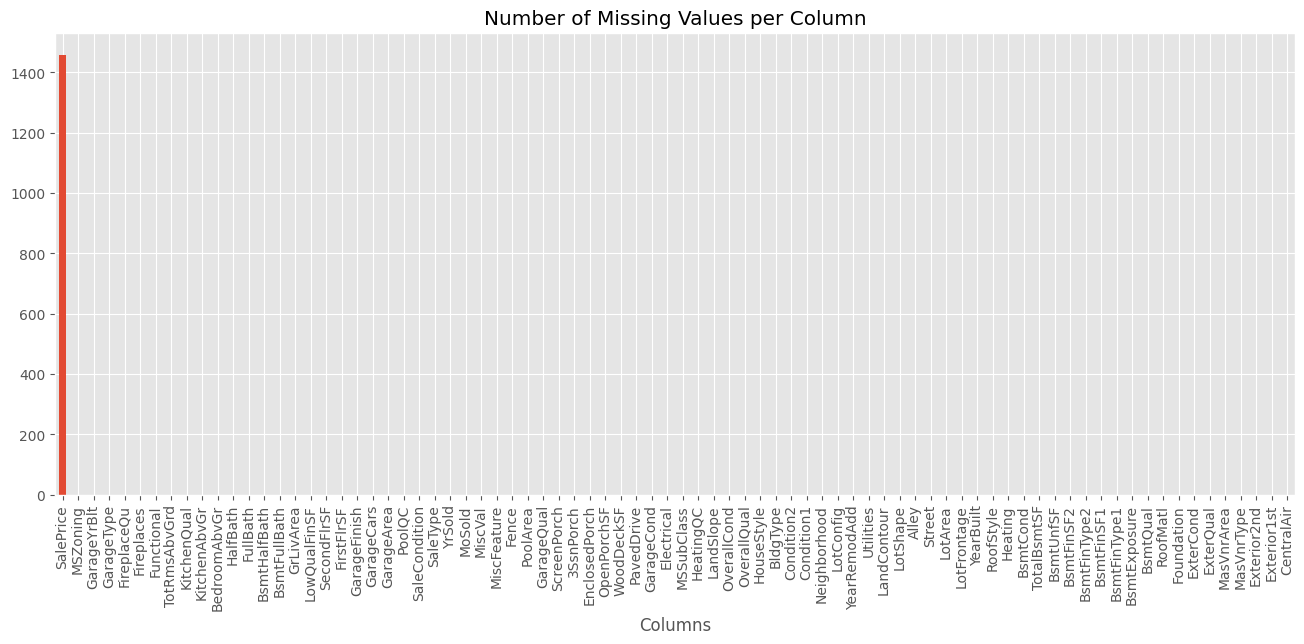

In [93]:
df.isna().sum().sort_values(ascending=False).plot(kind='bar', figsize=(16, 6))
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.show()



## Change datatypes

In [94]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,FirstFlrSF,SecondFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,None,1980.0,None,0.0,0.0,None,None,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal,NaN
2915,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml,NaN
2916,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml,NaN
2917,85,RL,62.0,10441,Pave,None,Reg,Lvl,AllPub,Inside,G

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuil

In [96]:
# Changing floats that are actually ints to ints

df['BsmtFullBath'] = df['BsmtFullBath'].astype(int)
df['BsmtHalfBath'] = df['BsmtHalfBath'].astype(int)
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageCars'] = df['GarageCars'].astype(int)


# Feature engineering

## Creating new features 
from the existing ones

In [97]:
# Features that have years in them
df['GarageYrBlt'] = df['YrSold'] - df['GarageYrBlt']
df['YearBuilt'] = df['YrSold'] - df['YearBuilt']
df['YearRemodAdd'] = df['YrSold'] - df['YearRemodAdd']

df.drop(['YrSold'], axis=1, inplace=True)
df.drop(['MoSold'], axis=1, inplace=True) #Isn't necessary

In [98]:
# Features that have square feet
df['BsmtFinSF'] = df['BsmtFinSF1'] + df['BsmtFinSF2']
df['TotalFlrSF'] = df['FirstFlrSF'] + df['SecondFlrSF']

df.drop(['BsmtFinSF1'], axis=1, inplace=True)
df.drop(['BsmtFinSF2'], axis=1, inplace=True)
df.drop(['FirstFlrSF'], axis=1, inplace=True)
df.drop(['SecondFlrSF'], axis=1, inplace=True)
df.drop(['TotalBsmtSF'], axis=1, inplace=True) # Isn't necessary since it's a sum of the other columns

In [99]:
# Features that are about bathrooms
df['TotalBaths'] = df['FullBath'] + (0.5*df['HalfBath']) + df['BsmtFullBath'] + (0.5*df['BsmtHalfBath'])

df.drop(['FullBath'], axis=1, inplace=True)
df.drop(['HalfBath'], axis=1, inplace=True)
df.drop(['BsmtFullBath'], axis=1, inplace=True)
df.drop(['BsmtHalfBath'], axis=1, inplace=True)

In [100]:
# Features about the garage
df['GarageAreaPerCar'] = df['GarageArea'] / df['GarageCars']

# Fill in any nulls from feature engineering
df['GarageAreaPerCar'].fillna(0, inplace=True)

df.drop(['GarageArea'], axis=1, inplace=True)
df.drop(['GarageCars'], axis=1, inplace=True)

## Skewness of the columns: 
NOT NEEDED IF USING TREE-BASED MODELS, BUT GOOD TO KNOW

In [101]:
# Create a list of the numerical data types after the feature engineering
numerical_cols = [cname for cname in df.columns if df[cname].dtypes!='object' and cname!='SalePrice']

# Create new dataframe with the numerical columns
skew_df = pd.DataFrame(numerical_cols, columns=['Feature'])

# This finction used to compute the skewness of a dataset
skew_df['Skew'] = skew_df['Feature'].apply(lambda feature: scipy.stats.skew(df[feature]))

# Change Skew to a postive number
skew_df['Absolute Skew'] = skew_df['Skew'].apply(abs)

# Create true/false columns based on if Absolute Skew is >=0.5
skew_df['Skewed'] = skew_df['Absolute Skew'].apply(lambda x: True if x >= 0.5 else False)

skew_df

,Feature,Skew,Absolute Skew,Skewed
0,MSSubClass,1.375457,1.375457,True
1,LotFrontage,1.652671,1.652671,True
2,LotArea,12.822431,12.822431,True
3,OverallQual,0.197110,0.197110,False
4,OverallCond,0.570312,0.570312,True
5,YearBuilt,0.598609,0.598609,True
6,YearRemodAdd,0.450226,0.450226,False
7,MasVnrArea,2.613592,2.613592,True
8,BsmtUnfSF,0.919339,0.919339,True
9,LowQualFinSF,12.088761,12.088761,True


In [102]:
if False:
    # Apply log1p transformation to df whose above a 0.5 absolute skew
    for column in skew_df.query("Skewed == True")['Feature'].values:
        df[column] = np.log1p(df[column])

## Deal with skew in the target variable

In [103]:
df["LogSalePrice"] = np.log(df["SalePrice"])

df = df.drop(['SalePrice'], axis=1)

LogSalePrice
NaN          1459
11.849398      20
11.813030      17
11.884489      14
11.951180      14
             ... 
12.219310       1
12.013095       1
12.109011       1
12.574182       1
12.246735       1
Name: count, Length: 664, dtype: int64


<Axes: >

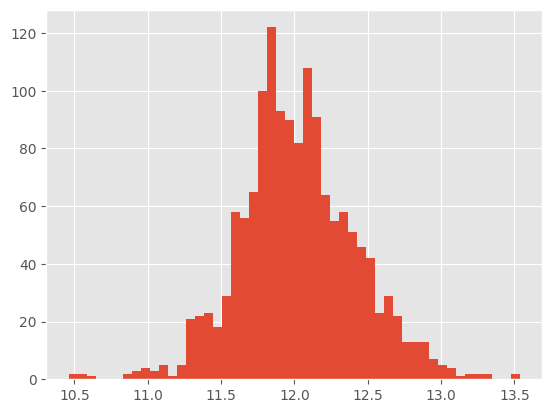

In [104]:
print(df["LogSalePrice"].value_counts(dropna=False))
df["LogSalePrice"].hist(bins=50)

## Encode categorical variables

In [105]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'],exclude=['object']).columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols, categorical_cols


(Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
        'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtUnfSF', 'LowQualFinSF',
        'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
        'Fireplaces', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF',
        'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
        'BsmtFinSF', 'TotalFlrSF', 'TotalBaths', 'GarageAreaPerCar',
        'LogSalePrice'],
       dtype='object'),
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
        'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
        'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',

### **Ordinal** encoding for ordered categories

In [106]:
# Encoding ordered categorical variables

import pandas as pd

ordinal_1 = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

quality_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

for col in ordinal_1:
    df[col] = df[col].map(quality_map).astype('int')  

In [107]:
# Ordered encode all the ordinal data individually, and add to list
ordinal_2 = ['LotShape', 'LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                'Utilities', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']

df['LotShape'] = df['LotShape'].map({"None":0,"IR3":1,"IR2":2,"IR1":3,"Reg":4}).astype('int')
df['LandContour'] = df['LandContour'].map({"None":0,"Low":1,"Bnk":2,"HLS":3,"Lvl":4}).astype('int')
df['LandSlope'] = df['LandSlope'].map({"None":0,"Sev":1,"Mod":2,"Gtl":3}).astype('int')
df['BsmtExposure'] = df['BsmtExposure'].map({"None":0, "No":1,"Mn":2,"Av":3,"Gd":4}).astype('int')
df['BsmtFinType1'] = df['BsmtFinType1'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['BsmtFinType2'] = df['BsmtFinType2'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['Utilities'] = df['Utilities'].map({"None":0,"ELO":1,"NoSeWa":2,"NoSewr":3,"AllPub":4}).astype('int')
df['CentralAir'] = df['CentralAir'].map({"None":0,"N":1,"Y":2}).astype('int')
df['Functional'] = df['Functional'].map({"None":0,"Sal":1,"Sev":2,"Maj2":3,"Maj1":4,"Mod":5,"Min2":6,
                                        "Min1":7,"Typ":8}).astype('int')
df['GarageFinish'] = df['GarageFinish'].map({"None":0,"Unf":1,"RFn":2,"Fin":3}).astype('int')
df['PavedDrive'] = df['PavedDrive'].map({"None":0,"N":1,"P":2,"Y":3}).astype('int')
df['Fence'] = df['Fence'].map({"None":0, "MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4}).astype('int')

### **Label** encoding for non-ordered categories

In [108]:
# For both xgboost and lightgbm you just need to use the category datatype for the categorical columns, and they will automatically do label encoding for you. You don't need to do anything to the ordinal columns since they are already encoded as integers.

labeled_cols = df.select_dtypes(include='object').columns

for col in labeled_cols:
    df[col] = df[col].astype('category')
    

temp = {}
for col in labeled_cols:
    temp[col] = df[col].value_counts()

temp

{'MSZoning': MSZoning
 RL         2265
 RM          460
 FV          139
 RH           26
 C (all)      25
 None          4
 Name: count, dtype: int64,
 'Street': Street
 Pave    2907
 Grvl      12
 Name: count, dtype: int64,
 'Alley': Alley
 None    2721
 Grvl     120
 Pave      78
 Name: count, dtype: int64,
 'LotConfig': LotConfig
 Inside     2133
 Corner      511
 CulDSac     176
 FR2          85
 FR3          14
 Name: count, dtype: int64,
 'Neighborhood': Neighborhood
 NAmes      443
 CollgCr    267
 OldTown    239
 Edwards    194
 Somerst    182
 NridgHt    166
 Gilbert    165
 Sawyer     151
 NWAmes     131
 SawyerW    125
 Mitchel    114
 BrkSide    108
 Crawfor    103
 IDOTRR      93
 Timber      72
 NoRidge     71
 StoneBr     51
 SWISU       48
 ClearCr     44
 MeadowV     37
 BrDale      30
 Blmngtn     28
 Veenker     24
 NPkVill     23
 Blueste     10
 Name: count, dtype: int64,
 'Condition1': Condition1
 Norm      2511
 Feedr      164
 Artery      92
 RRAn        50
 Po

### **Target** encoding with **Leave-one-out (LOO)** instead the non-ordered labels

#### Simple version for just one dataset

In [109]:
if False:
    tempdf = df.copy()
    labeled_cols = df.select_dtypes(include=['object','category']).columns


    def loo_target_encode(feature, target='SalePrice'):
        # 1. Calculate the sum and count per category
        grp = df.groupby(feature)[target]
        cat_sum = grp.transform('sum')
        cat_count = grp.transform('count')
        
        # 2. Apply the LOO formula: (Total Sum - Current Row Value) / (Total Count - 1)
        loo_encoded = (cat_sum - df[target]) / (cat_count - 1)
        
        # 3. Handle the "Single Observation" case (division by zero)
        # Most common approach: Fill with the global mean of the target
        global_mean = df[target].mean()
        loo_encoded = loo_encoded.fillna(global_mean)
        
        return loo_encoded

    for col in labeled_cols:
        tempdf[col] = loo_target_encode(col).astype('float')

    tempdf[labeled_cols]

#### More complicated version for when the inference dataset (with Nan targets) is merget into the same dataframe

In [110]:
if False:
    labeled_cols = df.select_dtypes(include=['object','category']).columns
    labeled_cols

    tempdf = df.copy()

    def loo_target_encode(feature, target='LogSalePrice'):

        train_mask = df[target].notnull()
        train_df = df[train_mask]
        
        # 2. Calculate training-only stats
        # We use a dictionary or a series to map these to the main dataframe
        cat_stats = train_df.groupby(feature)[target].agg(['sum', 'count'])
        global_sum = train_df[target].sum()
        global_count = len(train_df)
        global_mean = global_sum / global_count
        
        # 3. Map these training stats to the entire dataframe (including inference)
        # This creates temporary helper columns
        df_sum = df[feature].map(cat_stats['sum']).astype(float)  # float to allow for NaN when sum is 0
        df_count = df[feature].map(cat_stats['count']).astype(float)  # float to allow for NaN when count is 0
        
        # 4. Initialize the output column
        # We'll use the "Standard Mean" for everything first
        encoded = df_sum / df_count
        
        # 5. Apply LOO Logic specifically to Training rows
        # Formula: (Sum - Current Y) / (Count - 1)
        train_loo = (df_sum[train_mask] - df[target][train_mask]) / (df_count[train_mask] - 1)
        encoded.update(train_loo)
        
        # 6. Handle Singletons and New Categories in inference
        # If a category in inference wasn't in Train, df_count is NaN.
        # If a category in Train had count 1, train_loo is inf/NaN.
        
        # Calculate LOO Global Mean for Training singletons
        loo_global_mean = (global_sum - df[target][train_mask]) / (global_count - 1)
        
        # Fill gaps:
        # A) Training rows with 1 observation -> LOO Global Mean
        encoded.loc[train_mask] = encoded.loc[train_mask].fillna(loo_global_mean)
        
        # B) inference rows with categories not seen in training -> Global Mean
        encoded = encoded.fillna(global_mean)
        
        return encoded



    for col in labeled_cols:
        tempdf[col] = loo_target_encode(col).astype('float')

    tempdf


In [111]:
target_means = df.groupby("SaleCondition")['LogSalePrice'].mean()

target_means

SaleCondition
Abnorml    11.788774
AdjLand    11.529147
Alloca     11.914458
Family     11.869655
Normal     12.005034
Partial    12.447477
Name: LogSalePrice, dtype: float64

## **One-hot encoding** for linear regression and other models

In [112]:
labeled_cols = df.select_dtypes(include=['object','category']).columns
labeled_cols

Index(['MSZoning', 'Street', 'Alley', 'LotConfig', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
       'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [113]:
one_hot_columns = labeled_cols
df = pd.get_dummies(df, columns=one_hot_columns, prefix=one_hot_columns, drop_first=True) # it automatically drops the initial column

In [114]:
if False:
    dftemp = df.copy()
    one_hot_columns = ['Alley']

    dftemp = pd.get_dummies(dftemp, columns=one_hot_columns, prefix=one_hot_columns,drop_first=True) # it automatically drops the initial column
    dftemp

# Train Model

## Split df_train and into df_validate df_test for model

In [115]:
# Typical train/test split
if False:
    columns = [c for c in df.columns if c not in ['targe']]

    X = df[columns]
    y = df['target']
    X_validate, X_test, y_validate, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

    X_validate

In [116]:
df_train = df.iloc[:df_train.shape[0]]
df_inference = df.iloc[df_train.shape[0]:]

log_target = df_train["LogSalePrice"]

df_train = df_train.drop(['LogSalePrice'], axis=1)
df_inference = df_inference.drop(['LogSalePrice'], axis=1)

In [117]:
df_inference

,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtUnfSF,HeatingQC,CentralAir,LowQualFinSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar,MSZoning_FV,MSZoning_None,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_None,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_None,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_None,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1460,20,80.0,11622,4,4,4,3,5,6,49,49,0.0,3,3,3,3,1,3,2,270.0,3,2,0,896,2,1,3,5,8,0,0,49,1,3,3,3,140,0,0,0,120,0,0,3,0,612.0,896,1.0,730.000000,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,Fa

## Tune hyperparameters with optuna

### XGBoost

In [118]:
# Define objective function for Optuna for xgboost
def objective_xgb(trial):
    # Define hyperparameters to optimize
    xgboost_params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 0.6),
        'subsample': trial.suggest_uniform('subsample', 0.4, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
    }

    # Initialize models with suggested parameters
    xgb_model = XGBRegressor(**xgboost_params, verbosity=0)

    # Train models
    xgb_model.fit(df_train, log_target)

    # Calculate RMSE
    kf = KFold(n_splits=10)
    xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))

    # Return average RMSE
    return np.mean(xgb_rmse)

In [119]:
# # Optimize hyperparameters xgboost
# study_xgb = optuna.create_study(direction='minimize')
# study_xgb.optimize(objective_xgb, n_trials=50)

In [120]:
# best_params_xgb = study_xgb.best_params
# best_params_xgb



# {'n_estimators': 2794,
#  'learning_rate': 0.017363039293560027,
#  'colsample_bytree': 0.39670401505406117,
#  'subsample': 0.5816789348238951,
#  'min_child_weight': 2}

In [121]:
best_params_xgb = {'n_estimators': 2794,
 'learning_rate': 0.017363039293560027,
 'colsample_bytree': 0.39670401505406117,
 'subsample': 0.5816789348238951,
 'min_child_weight': 2}

In [122]:
# study_xgb.best_value

# 1.1253873295166898


In [123]:
# Use best parameters to train final models
xgb_model = XGBRegressor(**best_params_xgb, verbosity=0)

xgb_model.fit(df_train, log_target)

kf = KFold(n_splits=10)

xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))
print(np.mean(xgb_rmse))


1.1253873295166898


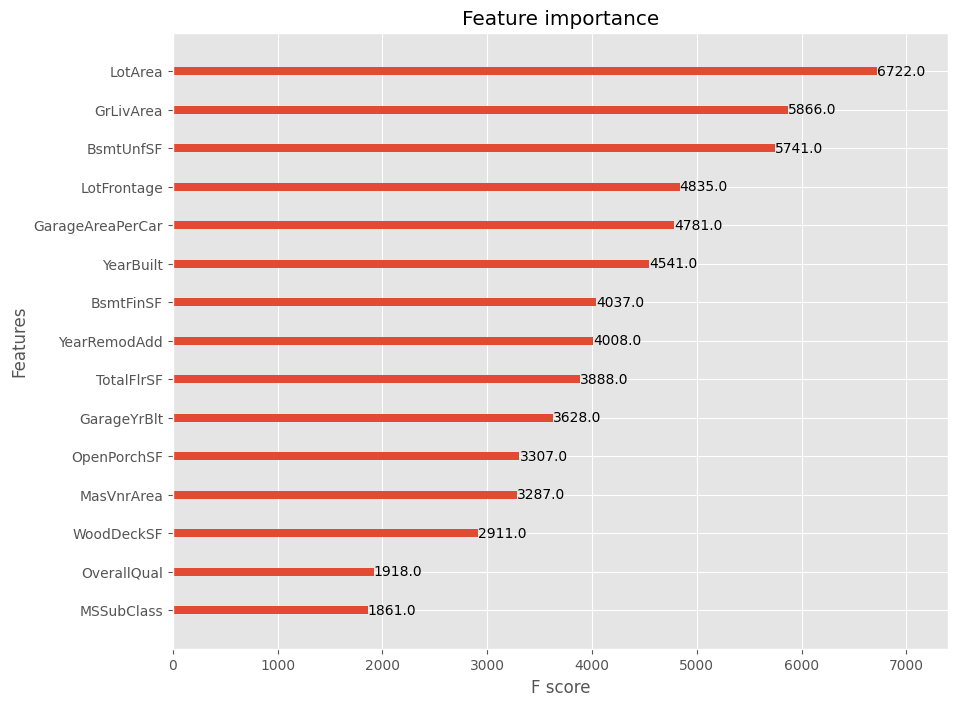

In [124]:
# Assuming your model is named xgb_model
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=15, ax=ax,importance_type='weight',) #weight, gain
plt.show()

### LightGBM

In [125]:


def objective_lgbm(trial):
    # Define hyperparameters to optimize
    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.6),
        'subsample': trial.suggest_float('subsample', 0.4, 0.8),
        # In LightGBM, bagging_freq is required to enable subsampling
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150), # LGBM is leaf-wise
        'verbosity': -1
    }

    # Initialize model
    lgbm_model = LGBMRegressor(**lgbm_params)

    # Calculate RMSE via Cross-Validation
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # We evaluate in log-space, then transform back
    # scoring='neg_mean_squared_error' returns negative values, so we use -score
    cv_scores = cross_val_score(lgbm_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)
    
    # Calculate the exponentiated RMSE (consistent with your log-transform logic)
    lgbm_rmse = np.exp(np.sqrt(-cv_scores))

    return np.mean(lgbm_rmse)

In [ ]:
# study_lgbm = optuna.create_study(direction='minimize')
# study_lgbm.optimize(objective_lgbm, n_trials=50)

# best_params_lgbm = study_lgbm.best_params
# print(f"Best Params: {best_params_lgbm}")



[I 2026-04-23 17:28:29,452] A new study created in memory with name: no-name-7a89b6dd-9ccb-4802-bd2b-686b3ce85c48
[I 2026-04-23 17:29:10,266] Trial 0 finished with value: 1.1311215980819103 and parameters: {'n_estimators': 7787, 'learning_rate': 0.008268372814970894, 'colsample_bytree': 0.4070841204114981, 'subsample': 0.7335068999043002, 'bagging_freq': 4, 'min_child_weight': 3, 'num_leaves': 57}. Best is trial 0 with value: 1.1311215980819103.
[I 2026-04-23 17:29:25,162] Trial 1 finished with value: 1.1339496443971921 and parameters: {'n_estimators': 3007, 'learning_rate': 0.03407848301699224, 'colsample_bytree': 0.41677239740181415, 'subsample': 0.6958686264388848, 'bagging_freq': 1, 'min_child_weight': 2, 'num_leaves': 144}. Best is trial 0 with value: 1.1311215980819103.
[I 2026-04-23 17:29:30,538] Trial 2 finished with value: 1.1330553582720106 and parameters: {'n_estimators': 1028, 'learning_rate': 0.011330688886619183, 'colsample_bytree': 0.5539492521685674, 'subsample': 0.7287

Best Params: {'n_estimators': 7150, 'learning_rate': 0.0074738726304694, 'colsample_bytree': 0.2903164459429457, 'subsample': 0.7040564660998244, 'bagging_freq': 6, 'min_child_weight': 5, 'num_leaves': 146}
Final LightGBM Mean RMSE: 1.1303418533133143


In [126]:
best_params_lgbm = {'n_estimators': 7150, 'learning_rate': 0.0074738726304694, 'colsample_bytree': 0.2903164459429457, 'subsample': 0.7040564660998244, 'bagging_freq': 6, 'min_child_weight': 5, 'num_leaves': 146}
# Final LightGBM Mean RMSE: 1.1303418533133143

In [127]:
# 3. Initialize the model with best parameters
# Note: verbosity=-1 is the LGBM equivalent to verbosity=0 in XGB
lgbm_model = LGBMRegressor(**best_params_lgbm, verbosity=-1)

# 4. Fit the final model
lgbm_model.fit(df_train, log_target)

# 5. Cross-validation to get the final reliable RMSE
kf = KFold(n_splits=10, shuffle=True, random_state=42)

lgbm_cv_scores = cross_val_score(lgbm_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)
lgbm_rmse = np.exp(np.sqrt(-lgbm_cv_scores))

print(f"Final LightGBM Mean RMSE: {np.mean(lgbm_rmse)}")

Final LightGBM Mean RMSE: 1.1303418533133143


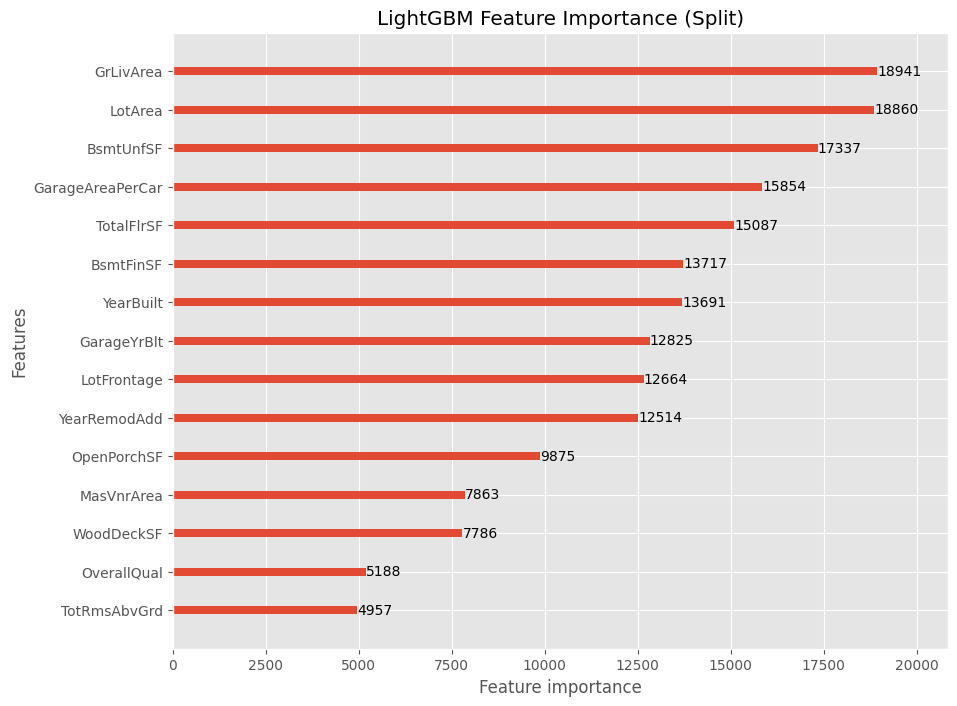

In [128]:
# Assuming your model is named lgbm_model
fig, ax = plt.subplots(figsize=(10, 8))

# max_num_features works exactly the same way
lgb.plot_importance(lgbm_model, max_num_features=15, ax=ax, importance_type='split') #split, gain

plt.title("LightGBM Feature Importance (Split)")
plt.show()

### OLS Linear regression

Lasso/Ridge needs feature scaling

In [129]:

# 1. Instantiate the model
# (Linear Regression is usually 'plug-and-play' with no hyperparameters)
lr_model = LinearRegression()

# 2. Fit the model on the log-transformed target
lr_model.fit(df_train, log_target)

# 3. Setup the K-Fold (using 10 splits as in your XGB example)
# Note: It's usually a good idea to add shuffle=True
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 4. Calculate CV scores
# We calculate RMSE in the log-space, then apply np.exp as per your strategy
lr_neg_mse = cross_val_score(lr_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)
lr_rmse = np.exp(np.sqrt(-lr_neg_mse))

print(f"Linear Regression Mean RMSE: {np.mean(lr_rmse)}")

Linear Regression Mean RMSE: 1.2057357524649677


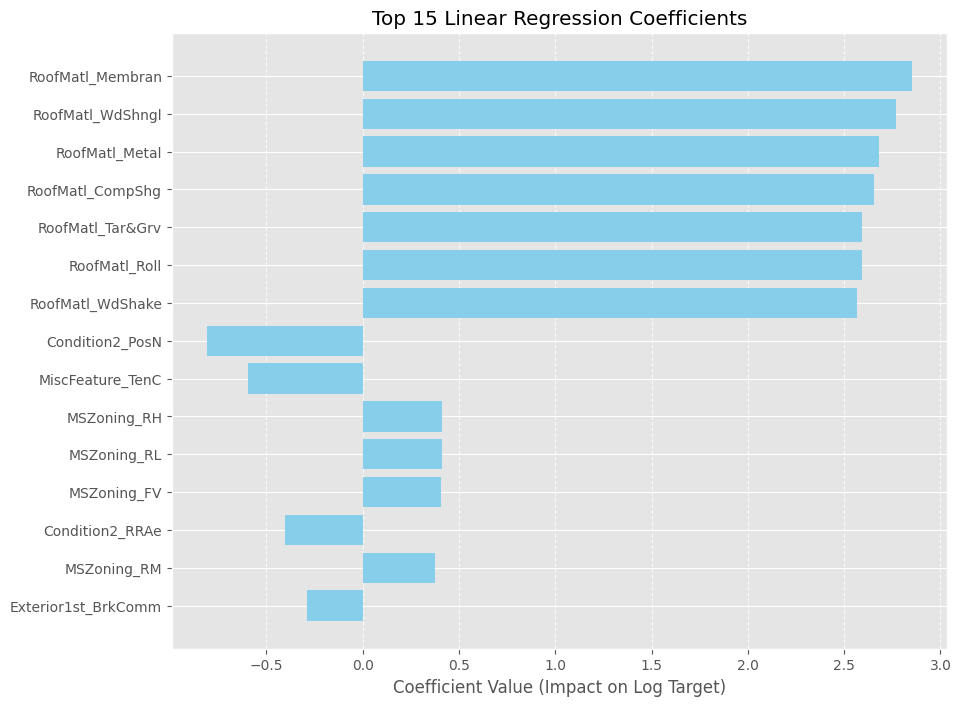

In [130]:
# 1. Extract coefficients and match them to feature names
# We use .coef_ for the weights and .feature_names_in_ if using a DataFrame
coef_df = pd.DataFrame({
    'Feature': df_train.columns,
    'Coefficient': lr_model.coef_
})

# 2. Sort by absolute value to see the most influential features first
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# 3. Plot
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value (Impact on Log Target)')
plt.title('Top 15 Linear Regression Coefficients')
plt.gca().invert_yaxis() # Highest impact at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Lasso

In [138]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Create a Pipeline
# This ensures StandardScaler is fit ONLY on the training folds and 
# applied to the validation fold, preventing leakage.
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1)) # 'alpha' is the regularization strength
])

# 2. Fit the model (on log-transformed target)
lasso_pipe.fit(df_train, log_target)

# 3. Setup K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 4. Calculate CV scores
# We use neg_mean_squared_error because cross_val_score maximizes a score
lasso_neg_mse = cross_val_score(lasso_pipe, df_train, log_target, 
                                scoring='neg_mean_squared_error', cv=kf)

# Convert MSE to RMSE and then reverse the log-transform
lasso_rmse = np.exp(np.sqrt(-lasso_neg_mse))

print(f"Lasso Regression Mean RMSE: {np.mean(lasso_rmse):.4f}")

Lasso Regression Mean RMSE: 1.2469


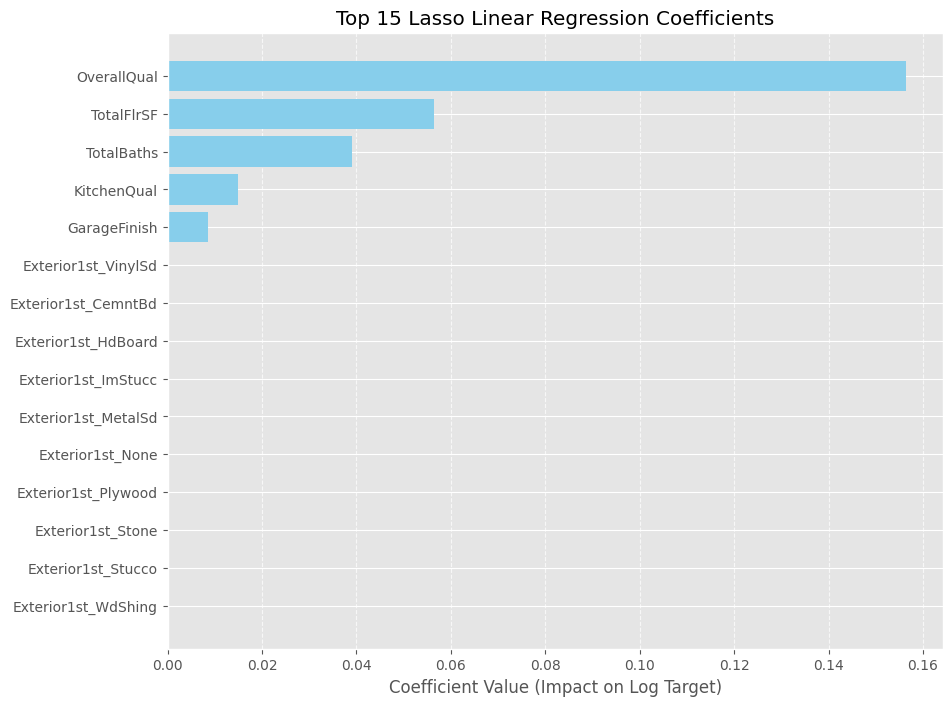

In [141]:
# 1. Extract coefficients and match them to feature names
# We use .coef_ for the weights and .feature_names_in_ if using a DataFrame


coef_df = pd.DataFrame({
    'Feature': df_train.columns,
    'Coefficient': lasso_pipe.named_steps['lasso'].coef_
})

# 2. Sort by absolute value to see the most influential features first
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# 3. Plot
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value (Impact on Log Target)')
plt.title('Top 15 Lasso Linear Regression Coefficients')
plt.gca().invert_yaxis() # Highest impact at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Ridge

In [145]:
from sklearn.linear_model import Ridge

# 1. Create a Pipeline
# Ridge adds a penalty proportional to the square of the magnitude of coefficients
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)) # alpha is the regularization strength
])

# 2. Fit the model on log-transformed target
ridge_pipe.fit(df_train, log_target)

# 3. Setup K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 4. Calculate CV scores
ridge_neg_mse = cross_val_score(ridge_pipe, df_train, log_target, 
                                scoring='neg_mean_squared_error', cv=kf)

# Convert to RMSE and reverse log-transform
ridge_rmse = np.exp(np.sqrt(-ridge_neg_mse))

print(f"Ridge Regression Mean RMSE: {np.mean(ridge_rmse):.4f}")

Ridge Regression Mean RMSE: 1.1998


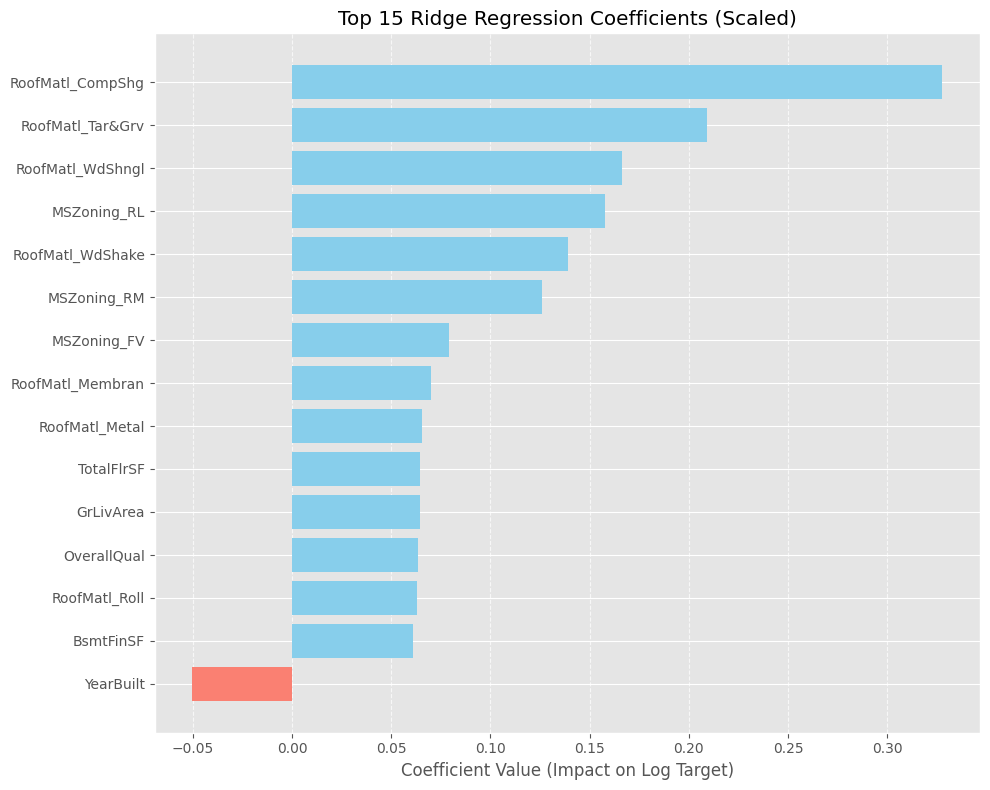

In [146]:
# 1. Extract coefficients from the 'ridge' step
ridge_model = ridge_pipe.named_steps['ridge']

coef_df = pd.DataFrame({
    'Feature': df_train.columns,
    'Coefficient': ridge_model.coef_
})

# 2. Sort by absolute value
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# 3. Plot
plt.figure(figsize=(10, 8))
colors = ['skyblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (Impact on Log Target)')
plt.title('Top 15 Ridge Regression Coefficients (Scaled)')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Elastic Net

In [147]:
from sklearn.linear_model import ElasticNet

# 1. Create a Pipeline
# l1_ratio: 1.0 is pure Lasso, 0.0 is pure Ridge. 0.5 is a 50/50 mix.
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(alpha=0.1, l1_ratio=0.5))
])

# 2. Fit the model
en_pipe.fit(df_train, log_target)

# 3. Setup K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 4. Calculate CV scores
en_neg_mse = cross_val_score(en_pipe, df_train, log_target, 
                             scoring='neg_mean_squared_error', cv=kf)

en_rmse = np.exp(np.sqrt(-en_neg_mse))

print(f"Elastic Net Mean RMSE: {np.mean(en_rmse):.4f}")

Elastic Net Mean RMSE: 1.2005


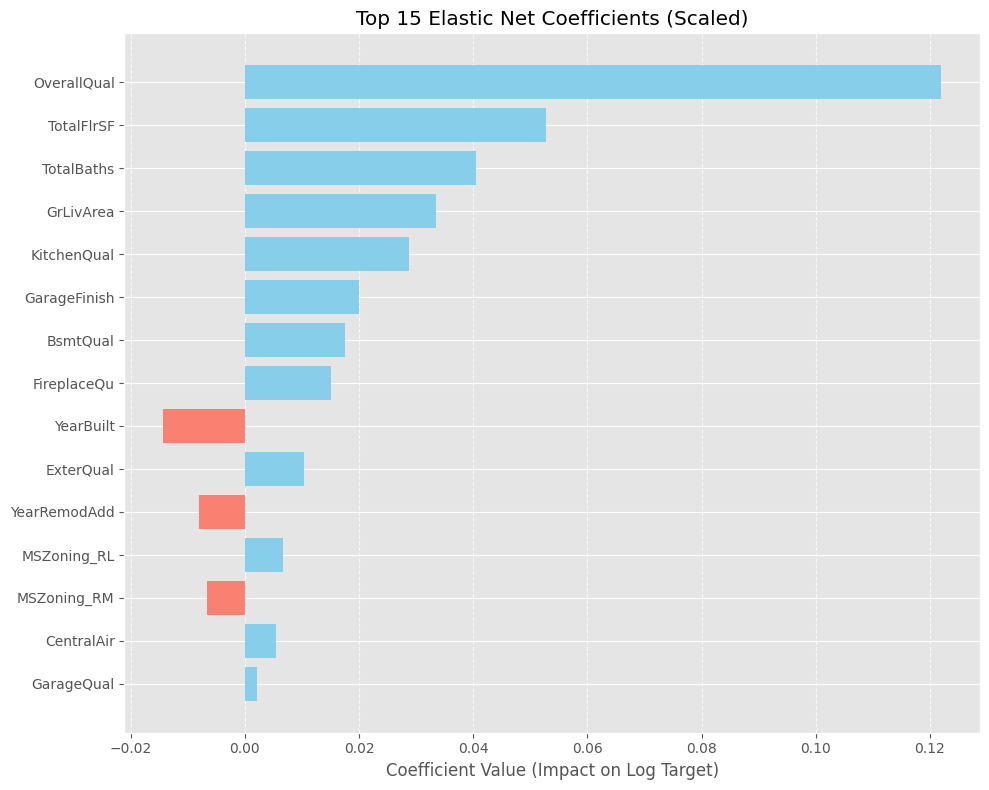

In [148]:
# 1. Extract coefficients
en_model = en_pipe.named_steps['elasticnet']

coef_df = pd.DataFrame({
    'Feature': df_train.columns,
    'Coefficient': en_model.coef_
})

# 2. Sort by absolute value
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

# 3. Plot
plt.figure(figsize=(10, 8))
colors = ['skyblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (Impact on Log Target)')
plt.title('Top 15 Elastic Net Coefficients (Scaled)')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Holdout predictions



If I had split the data into validate and holdout, so here this is not super valid because the models have been trained with the data in the test as well

In [136]:
# This is not important, I am just doing it to get the data frames already worked on.

df_train2 = df.iloc[:df_train.shape[0]]
df_inference2 = df.iloc[df_train.shape[0]:]




In [143]:
# Getting the validate/test split
# Here this is not proper because I am doing it after all the data processing, but I just want to have the dataframes ready to go for when I do the proper train/test split at the end.
columns = [c for c in df_train2.columns if c not in ['LogSalePrice']]

X = df_train2[columns]
y = df_train2['LogSalePrice']

X_validate, X_test, y_validate, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#,stratify=y)

X_validate

,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtUnfSF,HeatingQC,CentralAir,LowQualFinSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar,MSZoning_FV,MSZoning_None,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_None,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_None,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_None,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,20,70.0,8400,4,4,4,3,5,6,53,53,0.0,3,4,3,3,1,3,1,392.0,3,2,0,1314,3,1,3,5,8,0,0,53,2,3,3,3,250,0,0,0,0,0,0,0,0,922.0,1314,2.0,294.0,False,False,False,True,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,Fal

In [149]:
# 1. Run predictions on X_test
lr_preds = lr_model.predict(X_test)
lasso_pred = lasso_pipe.predict(X_test)
ridge_pred = ridge_pipe.predict(X_test)
en_pred = en_pipe.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

from sklearn.metrics import mean_squared_error
# 2. Calculate RMSE for each model
# Note: In sklearn 1.4+, use squared=False for RMSE
rmse_lr = mean_squared_error(y_test, lr_preds, squared=False)
rmse_lasso = mean_squared_error(y_test, lasso_pred, squared=False)
rmse_ridge = mean_squared_error(y_test, ridge_pred, squared=False)
rmse_en = mean_squared_error(y_test, en_pred, squared=False)
rmse_lgbm = mean_squared_error(y_test, lgbm_preds, squared=False)
rmse_xgb = mean_squared_error(y_test, xgb_preds, squared=False)

# 3. Print the results
print(f"Linear Regression RMSE: {np.exp(rmse_lr):.4f}")
print(f"Lasso Regression RMSE:  {np.exp(rmse_lasso):.4f}")
print(f"Ridge Regression RMSE:  {np.exp(rmse_ridge):.4f}")
print(f"Elastic Net RMSE:       {np.exp(rmse_en):.4f}")
print(f"LightGBM RMSE:          {np.exp(rmse_lgbm):.4f}")
print(f"XGBoost RMSE:           {np.exp(rmse_xgb):.4f}")

Linear Regression RMSE: 1.1043
Lasso Regression RMSE:  1.2614
Ridge Regression RMSE:  1.1047
Elastic Net RMSE:       1.2079
LightGBM RMSE:          1.0106
XGBoost RMSE:           1.0055


# Final Prediction

In [137]:
final_predictions = 0.6* np.exp(xgb_model.predict(df_inference)) + 0.4* np.exp(lgbm_model.predict(df_inference))


output = pd.DataFrame({'Id': df_inference.index+1, 'SalePrice': final_predictions})
output.to_csv('submission2.csv', index=False)